# **NOTE :** This project is the 5 th part of the project series and it also happens to be the one and only copy that is comprehensive of the compilation of the all the parts from Project 1 - Project 5.

**Part-1**

Problem Definition : How do geopolitical risks and hidden market regimes influence fluctuations in gold and silver prices

It is interesting to me because, both these rare metals are considered to be "safe-haven assests", and knowing how the global events affect their prices gives me the gravity of each particular news of the day to day events and it's impact on the global financial stability and investor behaviour.

By performing analysis on the gold and silver prices in the light of Geoplitical Risk Index, will allow us to know the relative sesitivity of the prices to the geoploitical tensions all around the globe

Population of interest : Global financial markets, specifically the daily prices of gold and silver

Sample: Daily gold and silver spot market data combined with the Geopolitical Risk Index (GPR) covering decades (1985-2019 and extended through 2025).

The indepenndent variables are :

*   GPR(Overall geoplitical risk index)
*   GPR_ACT(Realized Geopolitical Acts)
*   GPR_THREAT(Percieved Geoplitical Threats)
* VIX (measures stock market panic)
* 10Y_Treasury_Yield (Measures the "opportunity cost" of holding gold.)
* CPI (Measures inflation)
* WTI_CRUDE_OIL
* FED_FUNDS_RATE
* S&P_500


The depenndent variables are :
*   GOLD_CHANGE_% daily percentage change in gold price
*   SILVER_CHANGE_%daily percentage change in silver price

The Potential Confounders are:
*   US_DOLLAR_INDEX (DXY)
*   10Y_Treasury_Yield
*   Central bank policies (like the Federal Reserve raising rates).

To deal with cofounder variables:

- I would take the variables also into account as features for the classification of regimes in the k-means clustering model.

Hypothesis :
- H(0) = The relationship (correlation) between geopolitical risk (GPR) and gold's daily price changes is consistent across all market conditions. Any effect GPR has on gold is not dependent on other factors like market panic (VIX) or interest rates.
- h(1) = The relationship between geopolitical risk (GPR) and gold's daily price changes is state-dependent and varies significantly across different market regimes.

For the Data collection Part:

- The Data was combined from two websites and two API's and made into a dataset in kaggle.
- And this is a pre-existing dataset which is created by Tanishk Sharma and it has the License of "CC0: Public Domain" and I did take collect the data by downlading the csv file from kaggle website.



The source of the data is from :     
- Gold & Silver data: Investing.com (public financial data).
- Geopolitical Risk Index (GPRD): Matteo Iacoviello's official GPR website.
- These were used to create the dataset I am using and I got the dataset from kaggle.
- Market Data: Yahoo Finance API (via yfinance).
- Economic Data: St. Louis FRED database (via fredapi).

For Representativeness: The dataset Covers multiple decades of global trading data and geopolitical events, ensuring the dataset reflects both normal conditions and crises.

Link of the Dataset : https://www.kaggle.com/datasets/shreyanshdangi/gold-silver-price-vs-geopolitical-risk-19852025/data

This Dataset was updated 3 months ago

In [ ]:
import pandas as pd
df1 = pd.read_csv('/content/merged_final_2.csv')
print(df1.head())

   Unnamed: 0        DATE  GOLD_PRICE  GOLD_OPEN  GOLD_HIGH  GOLD_LOW  \
0           0  10/09/2025     3630.90    3633.61    3634.42   3620.90   
1           1  09/09/2025     3633.61    3637.10    3674.75   3625.33   
2           2  08/09/2025     3635.84    3586.82    3646.60   3579.67   
3           3  07/09/2025     3591.19    3592.07    3596.56   3586.95   
4           4  05/09/2025     3586.81    3547.00    3600.33   3540.05   

   GOLD_CHANGE_%  SILVER_PRICE  SILVER_OPEN  SILVER_HIGH  ...  GPRD_ACTS  \
0          -0.07         40.92        40.89        40.94  ...      97.42   
1          -0.06         40.89        41.34        41.50  ...      97.42   
2           1.24         41.36        41.01        41.68  ...      97.42   
3           0.12         40.86        41.00        41.01  ...     111.00   
4           1.15         41.01        40.69        41.44  ...     110.61   

   GPRD_THREAT_LEVEL  EVENT  US_DOLLAR_INDEX      S&P_500    VIX  \
0             146.26    NaN        9

**Part-2**

In [ ]:
import pandas as pd
df2 = pd.read_csv("/content/merged_file_FINAL.csv")

**2.**

* The Shape of the data is : (9291, 22).
* All the columns are of float data type, except 'Event', which is a object.
* These are the variables
GOLD_PRICE             GOLD_OPEN                 
GOLD_HIGH                
GOLD_LOW                  
GOLD_CHANGE_%                
SILVER_PRICE                
SILVER_OPEN               
SILVER_HIGH                
SILVER_LOW                  
SILVER_CHANGE_%             
GPR_INDEX                  
GPRD_ACTS                  
GPRD_THREAT_LEVEL           
EVENT                         
US_DOLLAR_INDEX        
S&P_500               
VIX                        
WTI_CRUDE_OIL              
10Y_TREASURY_YIELD           
FED_FUNDS_RATE               
CPI_INFLATION      
* There are are 9291 unique values
* Yes I have calculated it below


In [ ]:
df2.describe()

,GOLD_CHANGE_%,SILVER_PRICE,SILVER_OPEN,SILVER_HIGH,SILVER_LOW,SILVER_CHANGE_%,GPRD_THREAT_LEVEL,US_DOLLAR_INDEX,VIX,WTI_CRUDE_OIL,10Y_TREASURY_YIELD,FED_FUNDS_RATE,CPI_INFLATION
count,9291.00000,9287.000000,9287.000000,9287.000000,9287.000000,9287.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000
mean,0.02845,13.746370,13.730046,13.908386,13.563791,0.037305,115.434726,92.441330,19.448835,51.447022,4.251050,2.875516,209.276816
std,0.97568,9.431975,9.427505,9.597123,9.250411,1.733348,67.154545,10.118465,7.791299,29.176301,1.947447,2.360098,50.795949
min,-8.49000,3.540000,3.530000,3.540000,3.530000,-15.940000,7.890000,71.330002,9.140000,-36.980000,0.520000,0.040000,127.500000
25%,-0.43000,5.070000,5.060000,5.070000,5.060000,-0.750000,72.155000,84.424999,13.880000,22.430000,2.600000,0.210000,164.400000
50%,0.01000,13.120000,13.100000,13.310000,12.890000,0.000000,101.020000,92.529999,17.610001,48.650000,4.180000,2.500000,210.834000
75%,0.50000,19.505000,19.460000,19.740000,19.240000,0.880000,141.315000,98.919998,22.755000,73.775000,5.720000,5.210000,241.741000
max,11.00000,48.450000,48.420000,49.550000,47.520000,14.870000,809.490000,120.900002,82.690002,145.310000,9.090000,10.390000,323.364000


**3.**
* Yes I have mutliple datasets to be merged
* The first half was a dataset from kaggle with Gold price, Silver price along with Geo-political risk Index and the second half was pulled yahoo finance and the website of Federal Bank of St.louis.
* The first half was directly downloaded from kaggle and other was collected by doing API calls from FRED website and used yfinance library in python.

**4.**
* As these are all numerical and continuous data, there can be many duplicates and unique values, but they don't matter at all
* yes there were some missing data. they were of datatype float and object, it was related to silver prices (SILVER_PRICE
SILVER_OPEN
SILVER_HIGH
SILVER_LOW
SILVER_CHANGE_%) and the event column is mostly empty, it's  left to empty to add data for inference based on conclusions, regarding silver it was not expexted , but the event column was left empty for a reason (basically this is an extra column and it is not involved in the process, so it's just for making the predictions/ classification impactful, by adding historical events, at the end after the process).
* Initially few of the columns were mistaken as object datatype even though they only had numbers and the format of date was different every dataset, later it was changed to one common format, as it was the column that was common for merge.

* Yeah one column Header had a misspelling like: 10Y_TREASURY_***YEILD***
* Even though outliers could be found in this data, it's not possible to regard them as one, without knowing many external factor on what caused it and also determining what should be the correct value is totally based on past history and not on logic or intuition. So basically there are no outliers here, because the so-called outliers play the most important role in this project as being representation of historical events.


**5.**
Yes, there were reorganization in the column headers and these were the changes done directly in the file:
 * 10Y_TREASURY_YEILD to 10Y_TREASURY_YIELD
 * GPRD to GPR_Index
 * GPRD_ACT to GPRD_ACTS
 * GPRD_THREATt to GPRD_THREAT_LEVEL
 * CPI to CPI_Inflation


**6.**
My detailed Plan for data cleaning is:
1. For missing data some type of imputation has to be used and made sure that it is suitable for the nature of the data.
2. It's better to change all the numerical type data columns into one data type for uniformity and for smooth group execution.
3. Misspellings are changed with the proper spellings

**The techniques used for data cleaning:**

1. Following codes were run to find missing data and ipmuting the missing values with the avreage of values one cell above and below it to maintain the contionuous nature of the data.

In [ ]:
df2.isnull().sum() # for finding nuber of null values in each column

,0
DATE,0
GOLD_PRICE,0
GOLD_OPEN,0
GOLD_HIGH,0
GOLD_LOW,0
GOLD_CHANGE_%,0
SILVER_PRICE,4
SILVER_OPEN,4
SILVER_HIGH,4
SILVER_LOW,4


In [ ]:
rows_with_nan_in_col1 = df2[df2['SILVER_PRICE'].isna()] # to find the DATE of rows with the missinng values/Nan
print("\nRows with NaN in 'SILVER_PRICE':")
print(rows_with_nan_in_col1['DATE'])


Rows with NaN in 'SILVER_PRICE':
1486    25/12/2019
7733    25/12/1995
7993    26/12/1994
8336    01/09/1993
Name: DATE, dtype: object


2. The numerical columns with object datatype is changed to float, such that all the numerical columns are of float datatype. And the Date format was generalized to a common format in the file directly via MS Excel.

In [ ]:
cols_to_convert = ['GOLD_PRICE', 'GOLD_OPEN', 'GOLD_HIGH', 'GOLD_LOW', 'GPR_INDEX', 'GPRD_ACTS', 'S&P_500']

for col in cols_to_convert:
    if df2[col].dtype == 'object':
      df2[col] = df2[col].astype(str).str.replace(',', '', regex=False)
    df2[col] = pd.to_numeric(df2[col], errors='coerce')

display(df2.describe())

,GOLD_PRICE,GOLD_OPEN,GOLD_HIGH,GOLD_LOW,GOLD_CHANGE_%,SILVER_PRICE,SILVER_OPEN,SILVER_HIGH,SILVER_LOW,SILVER_CHANGE_%,GPR_INDEX,GPRD_ACTS,GPRD_THREAT_LEVEL,US_DOLLAR_INDEX,S&P_500,VIX,WTI_CRUDE_OIL,10Y_TREASURY_YIELD,FED_FUNDS_RATE,CPI_INFLATION
count,9291.000000,9291.000000,9291.000000,9291.000000,9291.00000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000
mean,955.768710,955.667676,961.572839,949.653348,0.02845,13.743948,13.727612,13.905905,13.561412,0.037131,111.435869,107.742876,115.434726,92.441330,1777.913651,19.448835,51.447022,4.251050,2.875516,209.276816
std,682.519015,681.976342,688.179276,676.257100,0.97568,9.431385,9.426897,9.596519,9.249831,1.733352,65.030048,98.187801,67.154545,10.118465,1373.766538,7.791299,29.176301,1.947447,2.360098,50.795949
min,252.550000,252.350000,252.550000,252.550000,-8.49000,3.540000,3.530000,3.540000,3.530000,-15.940000,9.490000,0.000000,7.890000,71.330002,295.459991,9.140000,-36.980000,0.520000,0.040000,127.500000
25%,366.250000,367.850000,366.250000,366.250000,-0.43000,5.070000,5.060000,5.070000,5.060000,-0.750000,74.170000,57.430000,72.155000,84.424999,919.149994,13.880000,22.430000,2.600000,0.210000,164.400000
50%,747.800000,747.450000,763.800000,738.000000,0.01000,13.120000,13.090000,13.310000,12.890000,0.000000,98.710000,87.800000,101.020000,92.529999,1295.859985,17.610001,48.650000,4.180000,2.500000,210.834000
75%,1358.025000,1358.445000,1367.635000,1346.115000,0.50000,19.500000,19.455000,19.735000,19.240000,0.880000,132.325000,131.415000,141.315000,98.919998,2170.905029,22.755000,73.775000,5.720000,5.210000,241.741000
max,3635.840000,3637.100000,3674.750000,3625.330000,11.00000,48.450000,48.420000,49.550000,47.520000,14.870000,1045.600000,1627.430000,809.490000,120.900002,6532.040039,82.690002,145.310000,9.090000,10.390000,323.364000


3. The Misspellings were changed directly in the file via MS Excel


**7. DATA CLEANING**

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9291 entries, 0 to 9290
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   DATE                9291 non-null   object 
 1   GOLD_PRICE          9291 non-null   float64
 2   GOLD_OPEN           9291 non-null   float64
 3   GOLD_HIGH           9291 non-null   float64
 4   GOLD_LOW            9291 non-null   float64
 5   GOLD_CHANGE_%       9291 non-null   float64
 6   SILVER_PRICE        9291 non-null   float64
 7   SILVER_OPEN         9291 non-null   float64
 8   SILVER_HIGH         9291 non-null   float64
 9   SILVER_LOW          9291 non-null   float64
 10  SILVER_CHANGE_%     9291 non-null   float64
 11  GPR_INDEX           9291 non-null   float64
 12  GPRD_ACTS           9291 non-null   float64
 13  GPRD_THREAT_LEVEL   9291 non-null   float64
 14  EVENT               10 non-null     object 
 15  US_DOLLAR_INDEX     9291 non-null   float64
 16  S&P_50

In [ ]:
df2.describe()

,GOLD_PRICE,GOLD_OPEN,GOLD_HIGH,GOLD_LOW,GOLD_CHANGE_%,SILVER_PRICE,SILVER_OPEN,SILVER_HIGH,SILVER_LOW,SILVER_CHANGE_%,GPR_INDEX,GPRD_ACTS,GPRD_THREAT_LEVEL,US_DOLLAR_INDEX,S&P_500,VIX,WTI_CRUDE_OIL,10Y_TREASURY_YIELD,FED_FUNDS_RATE,CPI_INFLATION
count,9291.000000,9291.000000,9291.000000,9291.000000,9291.00000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000
mean,955.768710,955.667676,961.572839,949.653348,0.02845,13.743948,13.727612,13.905905,13.561412,0.037131,111.435869,107.742876,115.434726,92.441330,1777.913651,19.448835,51.447022,4.251050,2.875516,209.276816
std,682.519015,681.976342,688.179276,676.257100,0.97568,9.431385,9.426897,9.596519,9.249831,1.733352,65.030048,98.187801,67.154545,10.118465,1373.766538,7.791299,29.176301,1.947447,2.360098,50.795949
min,252.550000,252.350000,252.550000,252.550000,-8.49000,3.540000,3.530000,3.540000,3.530000,-15.940000,9.490000,0.000000,7.890000,71.330002,295.459991,9.140000,-36.980000,0.520000,0.040000,127.500000
25%,366.250000,367.850000,366.250000,366.250000,-0.43000,5.070000,5.060000,5.070000,5.060000,-0.750000,74.170000,57.430000,72.155000,84.424999,919.149994,13.880000,22.430000,2.600000,0.210000,164.400000
50%,747.800000,747.450000,763.800000,738.000000,0.01000,13.120000,13.090000,13.310000,12.890000,0.000000,98.710000,87.800000,101.020000,92.529999,1295.859985,17.610001,48.650000,4.180000,2.500000,210.834000
75%,1358.025000,1358.445000,1367.635000,1346.115000,0.50000,19.500000,19.455000,19.735000,19.240000,0.880000,132.325000,131.415000,141.315000,98.919998,2170.905029,22.755000,73.775000,5.720000,5.210000,241.741000
max,3635.840000,3637.100000,3674.750000,3625.330000,11.00000,48.450000,48.420000,49.550000,47.520000,14.870000,1045.600000,1627.430000,809.490000,120.900002,6532.040039,82.690002,145.310000,9.090000,10.390000,323.364000


In [ ]:
cols_to_convert = ['GOLD_PRICE', 'GOLD_OPEN', 'GOLD_HIGH', 'GOLD_LOW', 'GPR_INDEX', 'GPRD_ACTS', 'S&P_500']

for col in cols_to_convert:
    if df2[col].dtype == 'object':
      df2[col] = df2[col].astype(str).str.replace(',', '', regex=False)
    df2[col] = pd.to_numeric(df2[col], errors='coerce')

In [ ]:
df2.describe()

,GOLD_PRICE,GOLD_OPEN,GOLD_HIGH,GOLD_LOW,GOLD_CHANGE_%,SILVER_PRICE,SILVER_OPEN,SILVER_HIGH,SILVER_LOW,SILVER_CHANGE_%,GPR_INDEX,GPRD_ACTS,GPRD_THREAT_LEVEL,US_DOLLAR_INDEX,S&P_500,VIX,WTI_CRUDE_OIL,10Y_TREASURY_YIELD,FED_FUNDS_RATE,CPI_INFLATION
count,9291.000000,9291.000000,9291.000000,9291.000000,9291.00000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000
mean,955.768710,955.667676,961.572839,949.653348,0.02845,13.743948,13.727612,13.905905,13.561412,0.037131,111.435869,107.742876,115.434726,92.441330,1777.913651,19.448835,51.447022,4.251050,2.875516,209.276816
std,682.519015,681.976342,688.179276,676.257100,0.97568,9.431385,9.426897,9.596519,9.249831,1.733352,65.030048,98.187801,67.154545,10.118465,1373.766538,7.791299,29.176301,1.947447,2.360098,50.795949
min,252.550000,252.350000,252.550000,252.550000,-8.49000,3.540000,3.530000,3.540000,3.530000,-15.940000,9.490000,0.000000,7.890000,71.330002,295.459991,9.140000,-36.980000,0.520000,0.040000,127.500000
25%,366.250000,367.850000,366.250000,366.250000,-0.43000,5.070000,5.060000,5.070000,5.060000,-0.750000,74.170000,57.430000,72.155000,84.424999,919.149994,13.880000,22.430000,2.600000,0.210000,164.400000
50%,747.800000,747.450000,763.800000,738.000000,0.01000,13.120000,13.090000,13.310000,12.890000,0.000000,98.710000,87.800000,101.020000,92.529999,1295.859985,17.610001,48.650000,4.180000,2.500000,210.834000
75%,1358.025000,1358.445000,1367.635000,1346.115000,0.50000,19.500000,19.455000,19.735000,19.240000,0.880000,132.325000,131.415000,141.315000,98.919998,2170.905029,22.755000,73.775000,5.720000,5.210000,241.741000
max,3635.840000,3637.100000,3674.750000,3625.330000,11.00000,48.450000,48.420000,49.550000,47.520000,14.870000,1045.600000,1627.430000,809.490000,120.900002,6532.040039,82.690002,145.310000,9.090000,10.390000,323.364000


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9291 entries, 0 to 9290
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   DATE                9291 non-null   object 
 1   GOLD_PRICE          9291 non-null   float64
 2   GOLD_OPEN           9291 non-null   float64
 3   GOLD_HIGH           9291 non-null   float64
 4   GOLD_LOW            9291 non-null   float64
 5   GOLD_CHANGE_%       9291 non-null   float64
 6   SILVER_PRICE        9291 non-null   float64
 7   SILVER_OPEN         9291 non-null   float64
 8   SILVER_HIGH         9291 non-null   float64
 9   SILVER_LOW          9291 non-null   float64
 10  SILVER_CHANGE_%     9291 non-null   float64
 11  GPR_INDEX           9291 non-null   float64
 12  GPRD_ACTS           9291 non-null   float64
 13  GPRD_THREAT_LEVEL   9291 non-null   float64
 14  EVENT               10 non-null     object 
 15  US_DOLLAR_INDEX     9291 non-null   float64
 16  S&P_50

In [ ]:
df2.isnull().sum()

,0
DATE,0
GOLD_PRICE,0
GOLD_OPEN,0
GOLD_HIGH,0
GOLD_LOW,0
GOLD_CHANGE_%,0
SILVER_PRICE,0
SILVER_OPEN,0
SILVER_HIGH,0
SILVER_LOW,0


In [ ]:
rows_with_nan_in_col1 = df2[df2['SILVER_PRICE'].isna()]
print("\nRows with NaN in 'SILVER_PRICE':")
print(rows_with_nan_in_col1['DATE'])


Rows with NaN in 'SILVER_PRICE':
Series([], Name: DATE, dtype: object)


In [ ]:
IMPUTATION_REQ = [1486,7733,7993,8336]
for i in IMPUTATION_REQ:
  df2.loc[i,'SILVER_PRICE'] = (df2.loc[i-1,'SILVER_PRICE'] + df2.loc[i+1,'SILVER_PRICE'])/2
  df2.loc[i,'SILVER_OPEN'] = (df2.loc[i-1,'SILVER_OPEN'] + df2.loc[i+1,'SILVER_OPEN'])/2
  df2.loc[i,'SILVER_HIGH'] = (df2.loc[i-1,'SILVER_HIGH'] + df2.loc[i+1,'SILVER_HIGH'])/2
  df2.loc[i,'SILVER_CHANGE_%'] = (df2.loc[i-1,'SILVER_CHANGE_%'] + df2.loc[i+1,'SILVER_CHANGE_%'])/2
  df2.loc[i,'SILVER_LOW'] = (df2.loc[i-1,'SILVER_LOW'] + df2.loc[i+1,'SILVER_LOW'])/2

In [ ]:
df2.isnull().sum()

,0
DATE,0
GOLD_PRICE,0
GOLD_OPEN,0
GOLD_HIGH,0
GOLD_LOW,0
GOLD_CHANGE_%,0
SILVER_PRICE,0
SILVER_OPEN,0
SILVER_HIGH,0
SILVER_LOW,0


In [ ]:
print(df2.iloc[1486])
print(" ")
print(df2.iloc[7733])
print(" ")
print(df2.iloc[7993])
print(" ")
print(df2.iloc[8336])

DATE                   25/12/2019
GOLD_PRICE                1499.55
GOLD_OPEN                 1499.55
GOLD_HIGH                 1499.55
GOLD_LOW                  1499.55
GOLD_CHANGE_%                 0.0
SILVER_PRICE                17.84
SILVER_OPEN                17.605
SILVER_HIGH                17.935
SILVER_LOW                  17.54
SILVER_CHANGE_%             1.325
GPR_INDEX                   45.38
GPRD_ACTS                   30.16
GPRD_THREAT_LEVEL           50.31
EVENT                         NaN
US_DOLLAR_INDEX         97.650002
S&P_500               3223.379883
VIX                         12.67
WTI_CRUDE_OIL               61.17
10Y_TREASURY_YIELD            1.9
FED_FUNDS_RATE               1.55
CPI_INFLATION              258.63
Name: 1486, dtype: object
 
DATE                  25/12/1995
GOLD_PRICE                 387.5
GOLD_OPEN                  387.5
GOLD_HIGH                  387.5
GOLD_LOW                   387.5
GOLD_CHANGE_%               0.06
SILVER_PRICE              

**8.** Save the cleaned data
**9.** Import the Cleaned data to a new file

In [ ]:
df2.to_csv("merged_final_2.csv")

**10.** Display
* The first 5 data entries from the cleaned data file
* The last 5 data entries from the cleaned data file

In [ ]:
print("Printing the first 5 data entries :")
print(df2.head(5))
print(" ")
print("Printing the last 5 data entries :")
print(df2.tail(5))

Printing the first 5 data entries :
         DATE  GOLD_PRICE  GOLD_OPEN  GOLD_HIGH  GOLD_LOW  GOLD_CHANGE_%  \
0  10/09/2025     3630.90    3633.61    3634.42   3620.90          -0.07   
1  09/09/2025     3633.61    3637.10    3674.75   3625.33          -0.06   
2  08/09/2025     3635.84    3586.82    3646.60   3579.67           1.24   
3  07/09/2025     3591.19    3592.07    3596.56   3586.95           0.12   
4  05/09/2025     3586.81    3547.00    3600.33   3540.05           1.15   

   SILVER_PRICE  SILVER_OPEN  SILVER_HIGH  SILVER_LOW  ...  GPRD_ACTS  \
0         40.92        40.89        40.94       40.72  ...      97.42   
1         40.89        41.34        41.50       40.77  ...      97.42   
2         41.36        41.01        41.68       40.51  ...      97.42   
3         40.86        41.00        41.01       40.76  ...     111.00   
4         41.01        40.69        41.44       40.55  ...     110.61   

   GPRD_THREAT_LEVEL  EVENT  US_DOLLAR_INDEX      S&P_500    VIX  \


**Part-3**

In [ ]:
import pandas as pd
df3 = pd.read_csv("/content/merged_final_2.csv")

**2.**

* Yes I think I have the right data, because almost all of the variables are correlated and I feel it's more than enough for the purpose fo the project.
*  My questions were related to how the varibles are correlated to each other.

**3.**
* The Shape of the data is : (9291, 22).
* Each row records the values of featuers on the on a given day within date range of the project.
* The variables are :

GOLD_HIGH

GOLD_LOW

GOLD_CHANGE_%

SILVER_PRICE

SILVER_OPEN

SILVER_HIGH

SILVER_LOW

SILVER_CHANGE_%

GPR_INDEX

GPRD_ACTS

GPRD_THREAT_LEVEL

EVENT

US_DOLLAR_INDEX

S&P_500

VIX

WTI_CRUDE_OIL

10Y_TREASURY_YIELD

FED_FUNDS_RATE

CPI_INFLATION

* There can be a lot of dupicate value but it's all necessary for the project because there is a high possibility that prices and rates may go through same value over the given time period, and that to be regarded as duplicates dosen't make any use.


**4.**
* Yes additional transformations / manipulations like log transformation was needed.

**5.**
* Except for the columns of Date (object) and Event (Object), every other column/feature is of float datatype.
*
GOLD_HIGH = $/pounce

GOLD_LOW = $/pounce

GOLD_CHANGE_% = it's a percentage

SILVER_PRICE = $/pounce

SILVER_OPEN = $/pounce

SILVER_HIGH = $/pounce

SILVER_LOW = $/pounce

SILVER_CHANGE_% = it's a percentage

GPR_INDEX = it's a relative measure between (0-500)

GPRD_ACTS = it's a relative measure between (0-500)

GPRD_THREAT_LEVEL = it's a relative measure between (0-800)

EVENT = its a blank column

US_DOLLAR_INDEX = Unitless Index Value. It measures the strength of the dollar against a basket of other currencies, relative to a starting value of 100

S&P_500 = Unitless Index Value

VIX = Percentage Points

WTI_CRUDE_OIL = $/Barrel of OIL

10Y_TREASURY_YIELD = it's a percentage

FED_FUNDS_RATE = it's a percentage

CPI_INFLATION = it's a percentage

* When the Values were compared it made only sense in these units, and i cross checked it with the internet.
* The Variables represent the following:
GOLD_PRICE = The daily closing price of gold

GOLD_OPEN = The daily opening price of gold

GOLD_HIGH = The highest price of gold reached during the day

GOLD_LOW = The lowest price of gold reached during the day

GOLD_CHANGE_% = The percentage change in gold's closing price from the previous day

SILVER_PRICE =The daily closing price of silver

SILVER_OPEN = The daily opening price of silver

SILVER_HIGH = The highest price of silver reached during the day

SILVER_LOW = The lowest price of silver reached during the day

SILVER_CHANGE_% = The percentage change in silver's closing price from the previous day

GPR_INDEX = The Overall score that combines both "Acts" and "Threats" to measure the total level of risk-related events

GPRD_ACTS = A sub-index that measures realized events

GPRD_THREAT_LEVEL = A sub-index that measures potential events

EVENT = A categorical(text) label.

US_DOLLAR_INDEX = It mesaures the strength of US dollars Against a basket of other major world currencies

S&P_500 = tracks the stock prices of 500 large U.S. companies. It's the most common benchmark for the overall "risk-on" stock market.

VIX = It measures the market's expectation of 30-day volatility in the S&P 500. This is a primary measure of market panic. AKA. "Fear Index".

WTI_CRUDE_OIL = The price of west texas intermediate crude oil.

10Y_TREASURY_YIELD = The interest rate paid on 10-year US goverment bonds.

FED_FUNDS_RATE = The target interest rate set by the US. Federal reserve.

CPI_INFLATION = The consumer price index.The most common measure of inflation.

* Yes I have done the log transformation, as mentioned in the 4 step.
* Yes there were few missing data, because some cells were empty at random.
* I have computed the descriptive statistics of all the varibles down
* I have also calculated the Z-score after the descriptive statistics.
* Actually, due to the continuous nature of the data it doesn't make any use in calculating the frequencies and even visualizing it, but I have calculated it after visualizing the Z-score.

In [ ]:
df3.describe()

,Unnamed: 0,GOLD_PRICE,GOLD_OPEN,GOLD_HIGH,GOLD_LOW,GOLD_CHANGE_%,SILVER_PRICE,SILVER_OPEN,SILVER_HIGH,SILVER_LOW,...,GPR_INDEX,GPRD_ACTS,GPRD_THREAT_LEVEL,US_DOLLAR_INDEX,S&P_500,VIX,WTI_CRUDE_OIL,10Y_TREASURY_YIELD,FED_FUNDS_RATE,CPI_INFLATION
count,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.00000,9291.000000,9291.000000,9291.000000,9291.000000,...,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000
mean,4645.000000,955.768710,955.667676,961.572839,949.653348,0.02845,13.743948,13.727612,13.905905,13.561412,...,111.435869,107.742876,115.434726,92.441330,1777.913651,19.448835,51.447022,4.251050,2.875516,209.276816
std,2682.225009,682.519015,681.976342,688.179276,676.257100,0.97568,9.431385,9.426897,9.596519,9.249831,...,65.030048,98.187801,67.154545,10.118465,1373.766538,7.791299,29.176301,1.947447,2.360098,50.795949
min,0.000000,252.550000,252.350000,252.550000,252.550000,-8.49000,3.540000,3.530000,3.540000,3.530000,...,9.490000,0.000000,7.890000,71.330002,295.459991,9.140000,-36.980000,0.520000,0.040000,127.500000
25%,2322.500000,366.250000,367.850000,366.250000,366.250000,-0.43000,5.070000,5.060000,5.070000,5.060000,...,74.170000,57.430000,72.155000,84.424999,919.149994,13.880000,22.430000,2.600000,0.210000,164.400000
50%,4645.000000,747.800000,747.450000,763.800000,738.000000,0.01000,13.120000,13.090000,13.310000,12.890000,...,98.710000,87.800000,101.020000,92.529999,1295.859985,17.610001,48.650000,4.180000,2.500000,210.834000
75%,6967.500000,1358.025000,1358.445000,1367.635000,1346.115000,0.50000,19.500000,19.455000,19.735000,19.240000,...,132.325000,131.415000,141.315000,98.919998,2170.905029,22.755000,73.775000,5.720000,5.210000,241.741000
max,9290.000000,3635.840000,3637.100000,3674.750000,3625.330000,11.00000,48.450000,48.420000,49.550000,47.520000,...,1045.600000,1627.430000,809.490000,120.900002,6532.040039,82.690002,145.310000,9.090000,10.390000,323.364000


In [ ]:
from scipy.stats import zscore

df3_numerical = df3.drop(columns=['DATE', 'Unnamed: 0', 'EVENT'])

df3_zscore_scipy = df3_numerical.apply(zscore)
print(df3_zscore_scipy.head())

   GOLD_PRICE  GOLD_OPEN  GOLD_HIGH  GOLD_LOW  GOLD_CHANGE_%  SILVER_PRICE  \
0    3.919708   3.926949   3.884149  3.950259      -0.100910      2.881604   
1    3.923679   3.932067   3.942756  3.956810      -0.090660      2.878423   
2    3.926946   3.858336   3.901849  3.889287       1.241816      2.928259   
3    3.861523   3.866035   3.829132  3.900053       0.093837      2.875242   
4    3.855106   3.799944   3.834610  3.830697       1.149568      2.891147   

   SILVER_OPEN  SILVER_HIGH  SILVER_LOW  SILVER_CHANGE_%  GPR_INDEX  \
0     2.881526     2.817225    2.936275         0.030503   0.089565   
1     2.929264     2.875582    2.941681        -0.673374   0.089565   
2     2.894256     2.894340    2.913571         0.670915   0.089565   
3     2.893195     2.824519    2.940600        -0.217585  -0.429453   
4     2.860309     2.869330    2.917895         0.417058   0.845564   

   GPRD_ACTS  GPRD_THREAT_LEVEL  US_DOLLAR_INDEX   S&P_500       VIX  \
0  -0.105140           0.459045 

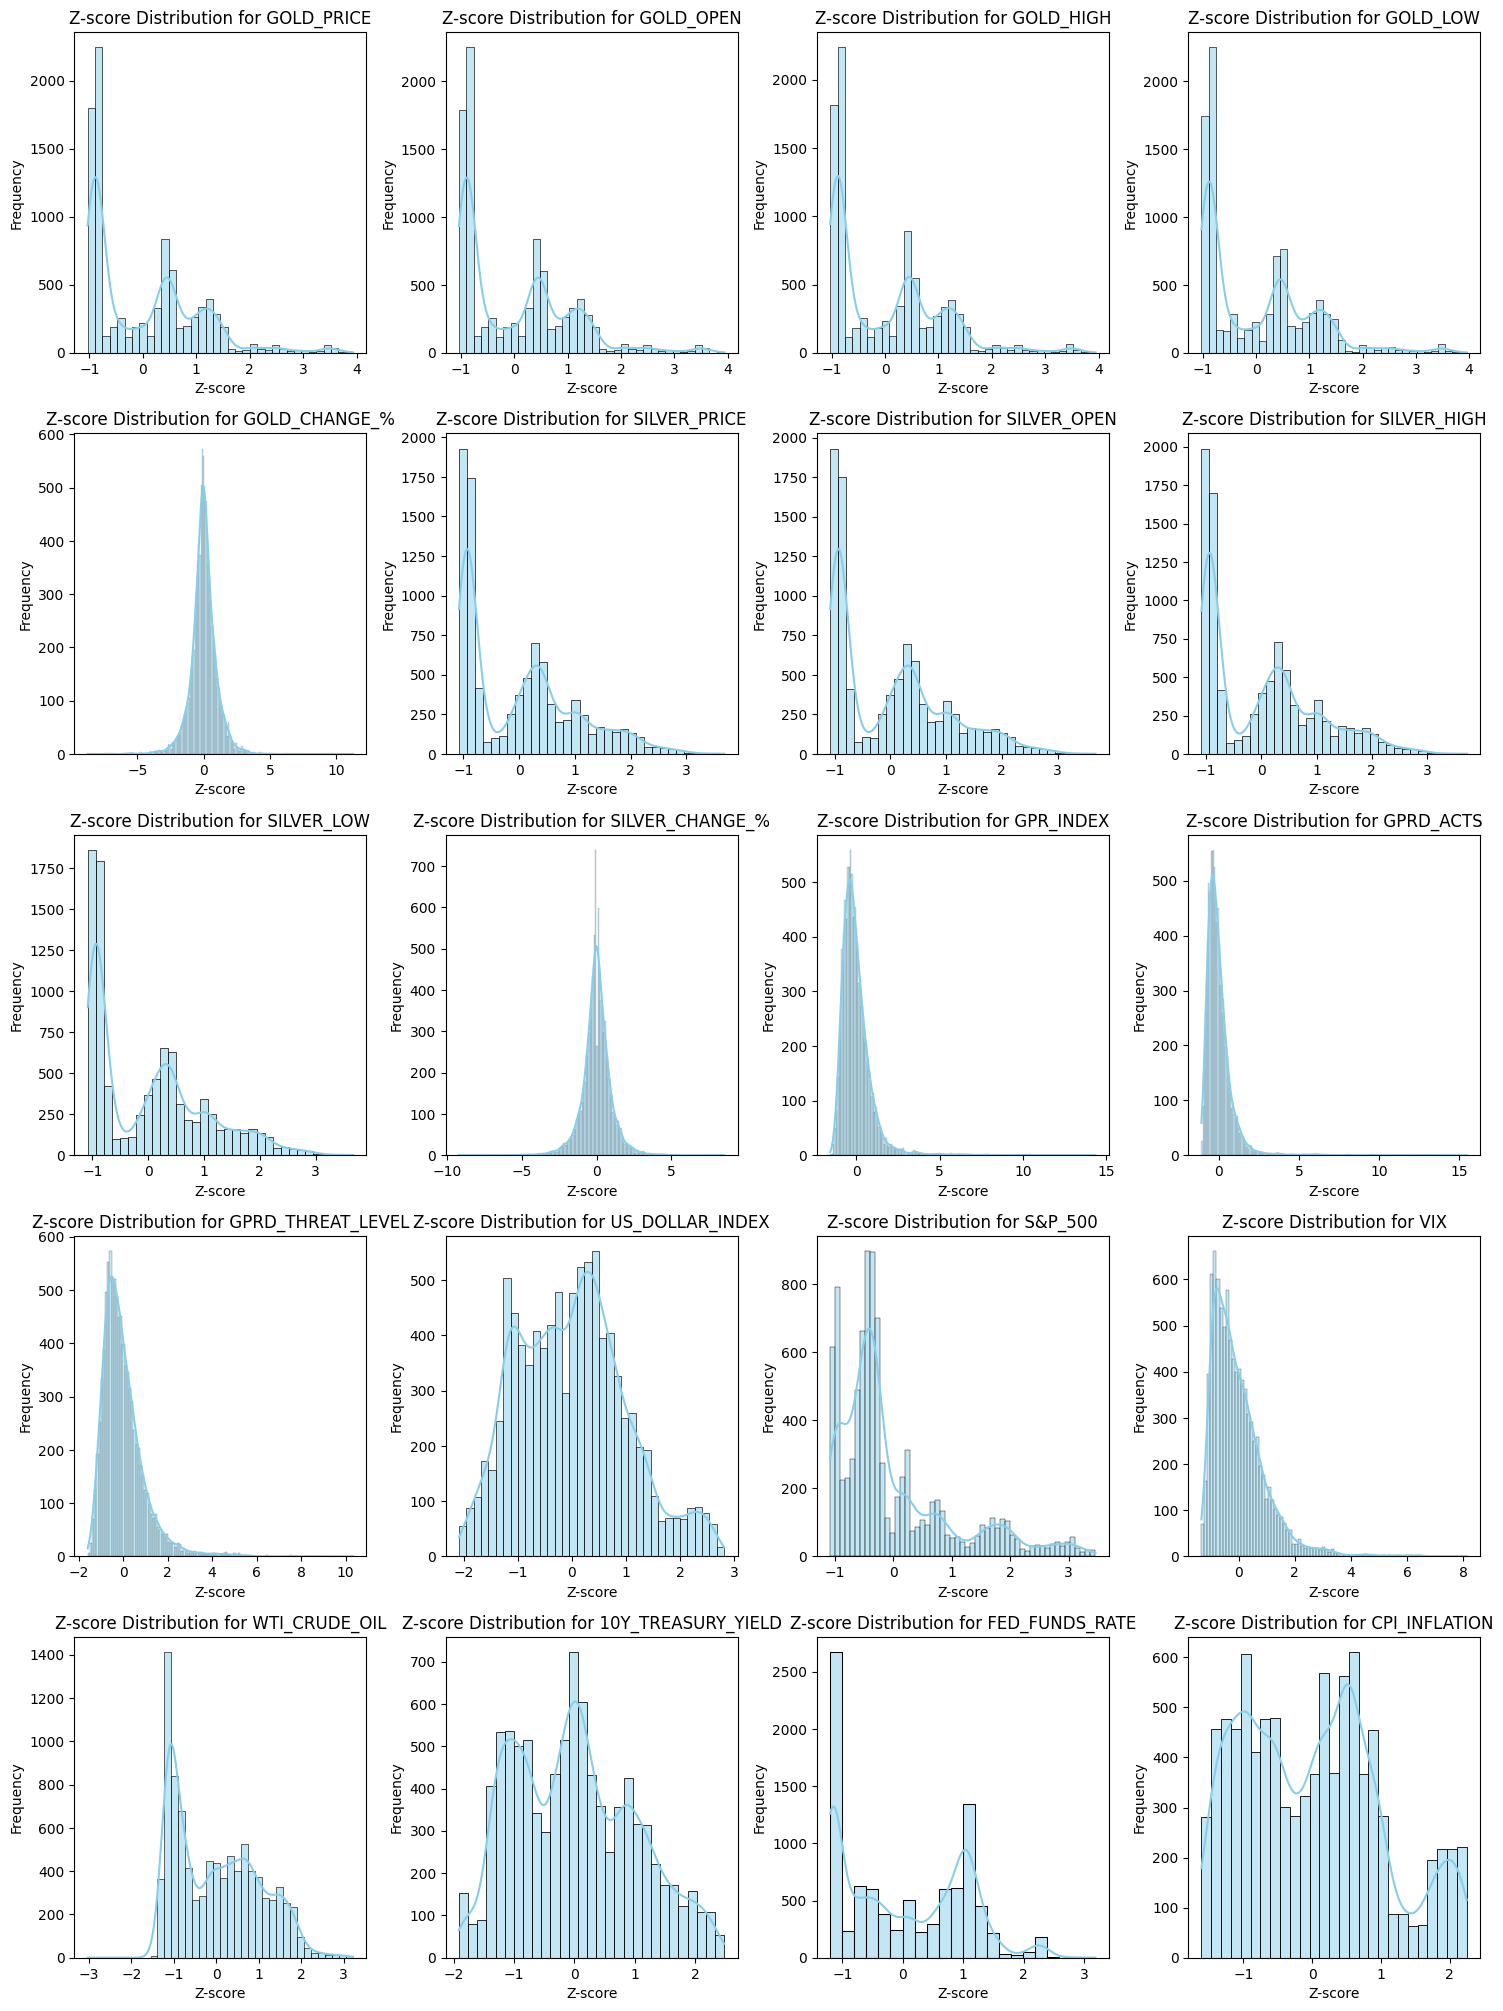

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

numerical_cols = df3_zscore_scipy.select_dtypes(include=np.number).columns
n_cols = len(numerical_cols)
n_rows = (n_cols + 3)

plt.figure(figsize=(15, n_rows * 4))

for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, 4, i + 1)
    sns.histplot(df3_zscore_scipy[f'{col}'], kde=True, color='skyblue')
    plt.title(f'Z-score Distribution for {col}')
    plt.xlabel('Z-score')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
for column in df3.columns:
    print(f"Frequency for column '{column}':")
    print(df3[column].value_counts())
    print("\n")

Frequency for column 'Unnamed: 0':
Unnamed: 0
9290    1
0       1
1       1
2       1
3       1
       ..
15      1
14      1
13      1
12      1
11      1
Name: count, Length: 9291, dtype: int64


Frequency for column 'DATE':
DATE
02/01/1990    1
10/09/2025    1
09/09/2025    1
08/09/2025    1
07/09/2025    1
             ..
21/08/2025    1
22/08/2025    1
25/08/2025    1
26/08/2025    1
27/08/2025    1
Name: count, Length: 9291, dtype: int64


Frequency for column 'GOLD_PRICE':
GOLD_PRICE
385.75     11
384.50     10
383.55      9
383.25      9
382.60      9
           ..
1200.35     1
1209.14     1
1228.19     1
1208.74     1
1128.85     1
Name: count, Length: 7256, dtype: int64


Frequency for column 'GOLD_OPEN':
GOLD_OPEN
383.45     11
382.55     11
391.25     11
384.75     10
359.25     10
           ..
1062.89     1
1060.73     1
1072.85     1
1051.72     1
1064.55     1
Name: count, Length: 7292, dtype: int64


Frequency for column 'GOLD_HIGH':
GOLD_HIGH
385.75     11
384.50    

**6.**
* GPR_INDEX, GPR_ACT, GPR_Threat, VIX, 10Y_TERASURY_YEILD, CPI, WTI_CRUDE_OIL, FED_FUNDS_RATE,S&P_500 are all independent and The price of Gold and silver is dependent on CPI, S&P_500, WTI_CRUDE_OIL
* I have tried correlation between useful variables down here, after the current text box.
* From the heatmap it's evident that GPR and GOLD/SILVER prices are very weakly correlated and GOLD/SILVER prices are positively correlated with CPI, S&P_500,WTI_CRUDE_OIL ( CPI > S&P_500 > WTI_CRUDE_OIL in the respective strength order).

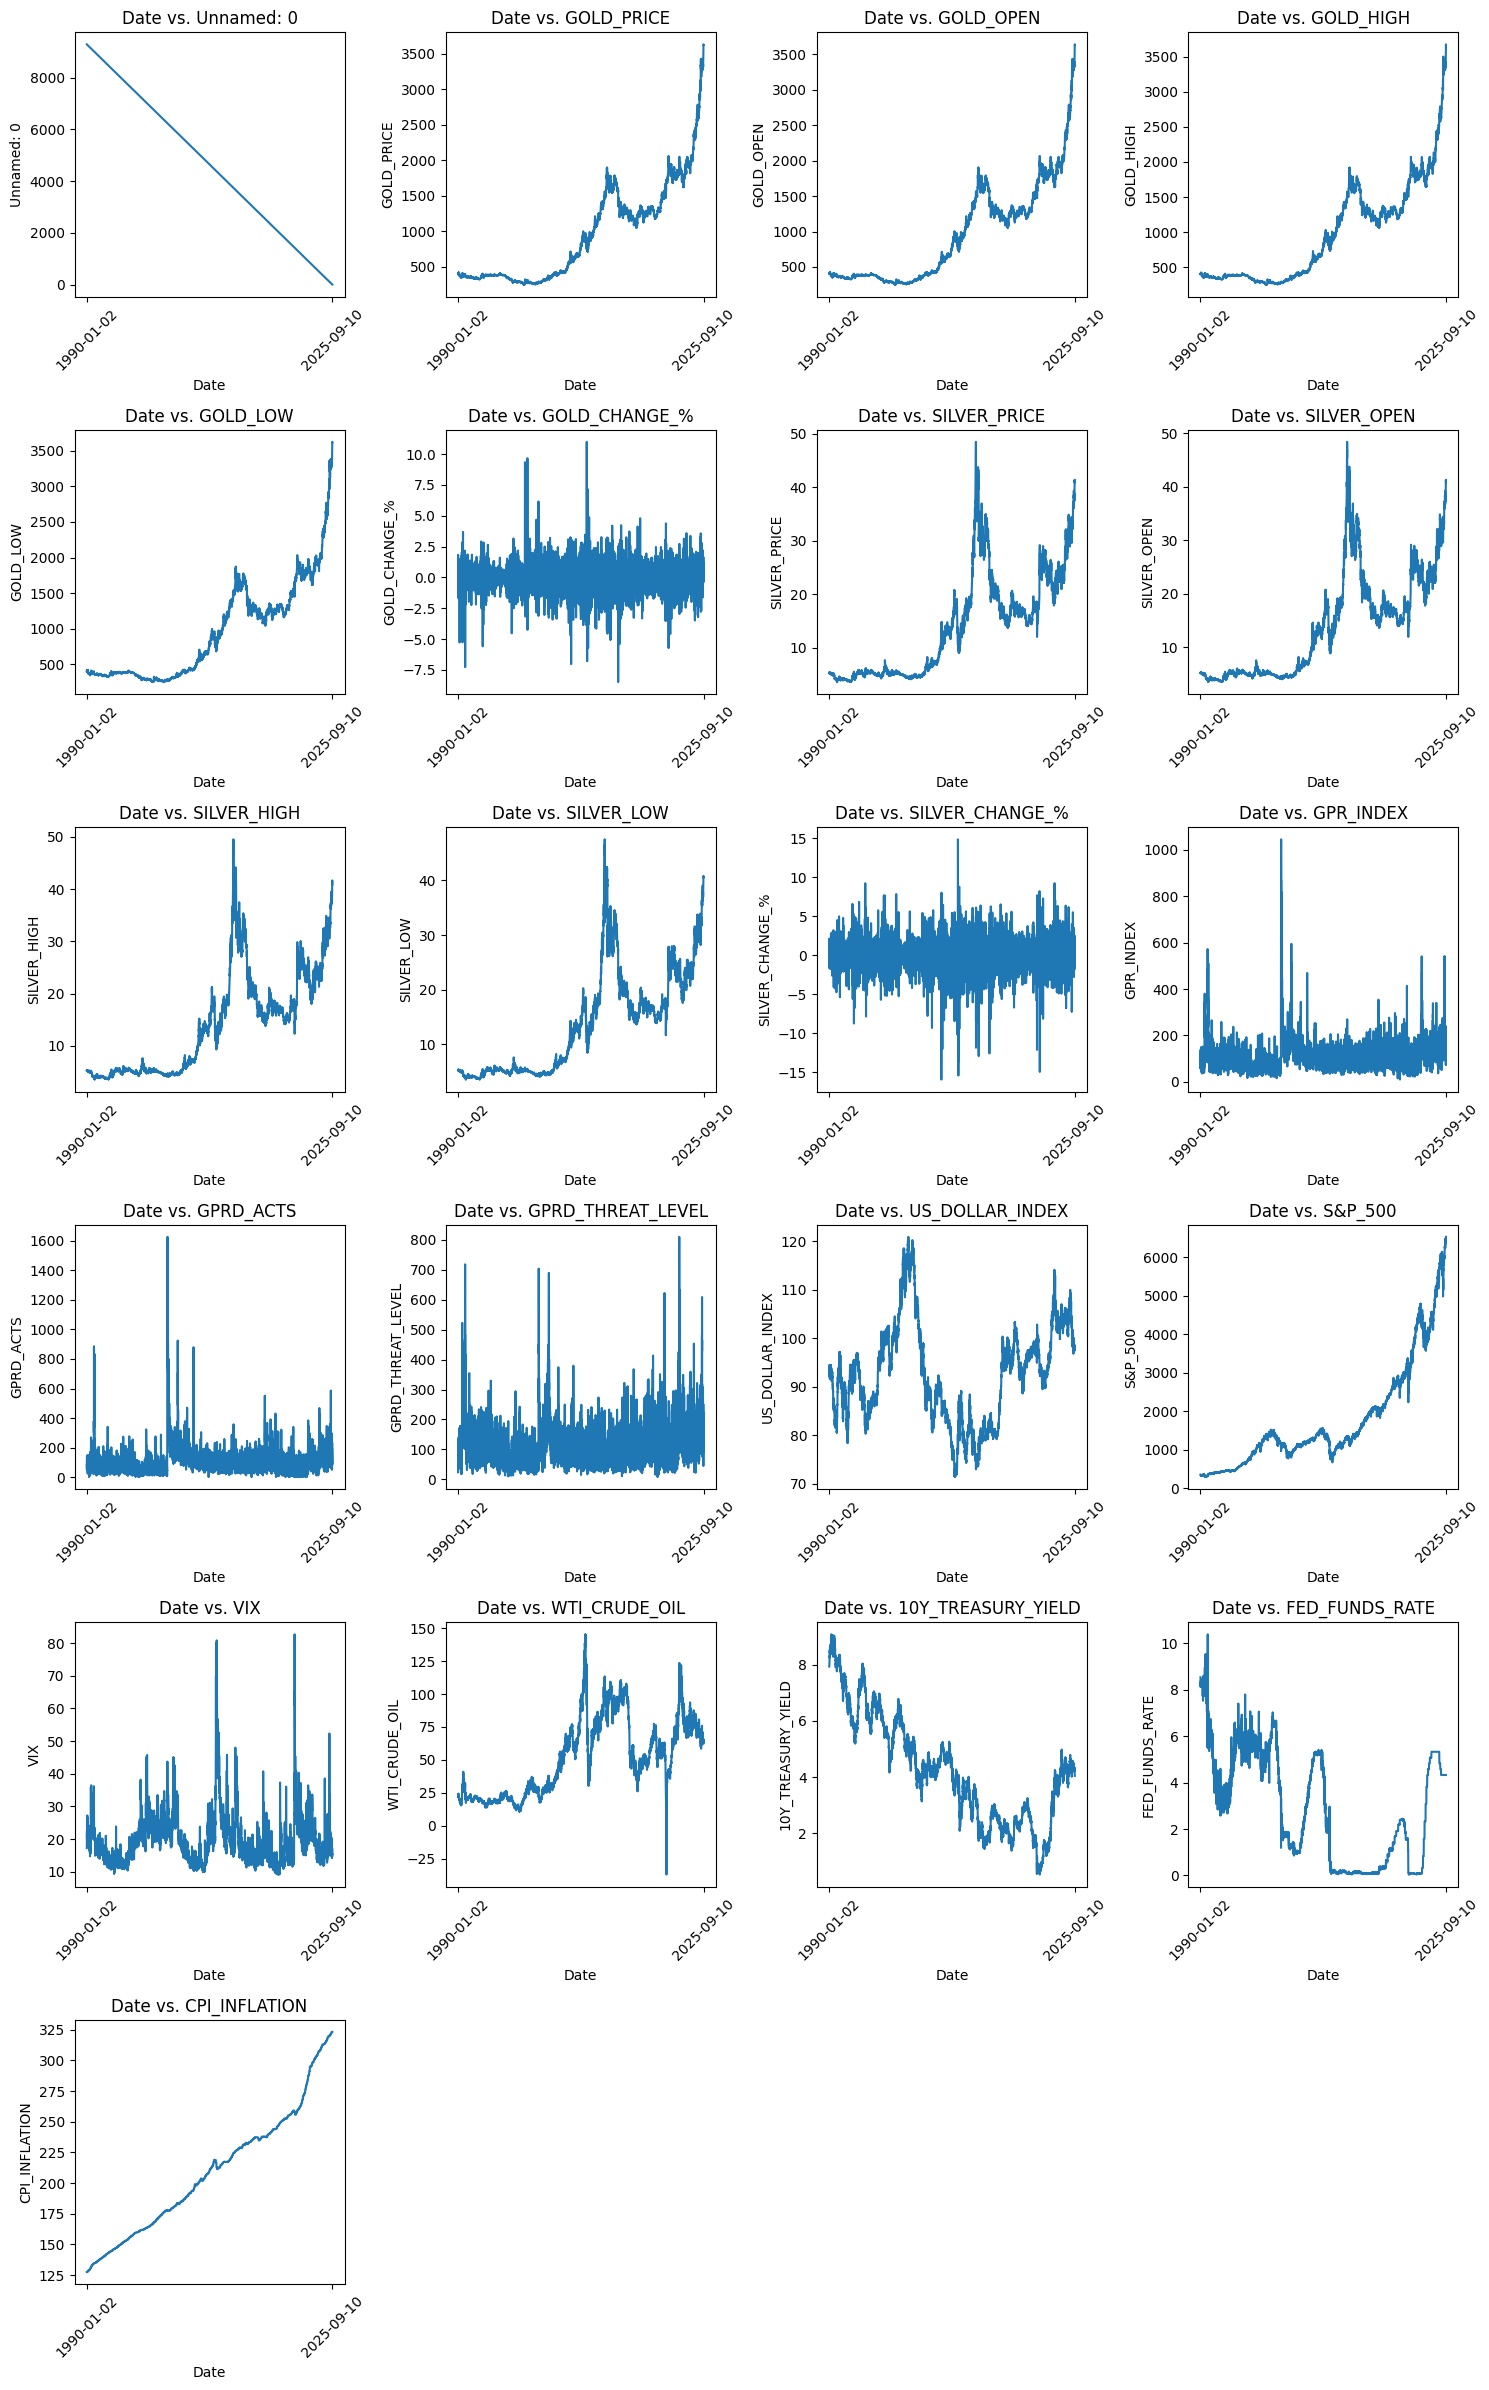

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

df3['DATE'] = pd.to_datetime(df3['DATE'], dayfirst=True)

df3 = df3.sort_values(by='DATE')

first_date = df3['DATE'].iloc[0]
last_date = df3['DATE'].iloc[-1]

date_ticks = [first_date, last_date]

date_labels = [first_date.strftime('%Y-%m-%d'), last_date.strftime('%Y-%m-%d')]

numerical_cols = df3.select_dtypes(include=np.number).columns
n_cols = len(numerical_cols)
n_rows = (n_cols + 3) // 4

plt.figure(figsize=(15, n_rows * 4))

for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, 4, i + 1)
    plt.plot(df3['DATE'], df3[f'{col}'])
    plt.title(f'Date vs. {col}')
    plt.xlabel('Date')
    plt.ylabel(f'{col}')

    plt.xticks(ticks=date_ticks, labels=date_labels, rotation=45)


plt.tight_layout()
plt.show()

In [ ]:
df3.describe()

,Unnamed: 0,DATE,GOLD_PRICE,GOLD_OPEN,GOLD_HIGH,GOLD_LOW,GOLD_CHANGE_%,SILVER_PRICE,SILVER_OPEN,SILVER_HIGH,...,GPR_INDEX,GPRD_ACTS,GPRD_THREAT_LEVEL,US_DOLLAR_INDEX,S&P_500,VIX,WTI_CRUDE_OIL,10Y_TREASURY_YIELD,FED_FUNDS_RATE,CPI_INFLATION
count,9291.000000,9291,9291.000000,9291.000000,9291.000000,9291.000000,9291.00000,9291.000000,9291.000000,9291.000000,...,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000,9291.000000
mean,4645.000000,2007-11-05 17:56:05.192121344,955.768710,955.667676,961.572839,949.653348,0.02845,13.743948,13.727612,13.905905,...,111.435869,107.742876,115.434726,92.441330,1777.913651,19.448835,51.447022,4.251050,2.875516,209.276816
min,0.000000,1990-01-02 00:00:00,252.550000,252.350000,252.550000,252.550000,-8.49000,3.540000,3.530000,3.540000,...,9.490000,0.000000,7.890000,71.330002,295.459991,9.140000,-36.980000,0.520000,0.040000,127.500000
25%,2322.500000,1998-12-03 12:00:00,366.250000,367.850000,366.250000,366.250000,-0.43000,5.070000,5.060000,5.070000,...,74.170000,57.430000,72.155000,84.424999,919.149994,13.880000,22.430000,2.600000,0.210000,164.400000
50%,4645.000000,2007-11-08 00:00:00,747.800000,747.450000,763.800000,738.000000,0.01000,13.120000,13.090000,13.310000,...,98.710000,87.800000,101.020000,92.529999,1295.859985,17.610001,48.650000,4.180000,2.500000,210.834000
75%,6967.500000,2016-10-05 12:00:00,1358.025000,1358.445000,1367.635000,1346.115000,0.50000,19.500000,19.455000,19.735000,...,132.325000,131.415000,141.315000,98.919998,2170.905029,22.755000,73.775000,5.720000,5.210000,241.741000
max,9290.000000,2025-09-10 00:00:00,3635.840000,3637.100000,3674.750000,3625.330000,11.00000,48.450000,48.420000,49.550000,...,1045.600000,1627.430000,809.490000,120.900002,6532.040039,82.690002,145.310000,9.090000,10.390000,323.364000
std,2682.225009,NaN,682.519015,681.976342,688.179276,676.257100,0.97568,9.431385,9.426897,9.596519,...,65.030048,98.187801,67.154545,10.118465,1373.766538,7.791299,29.176301,1.947447,2.360098,50.795949


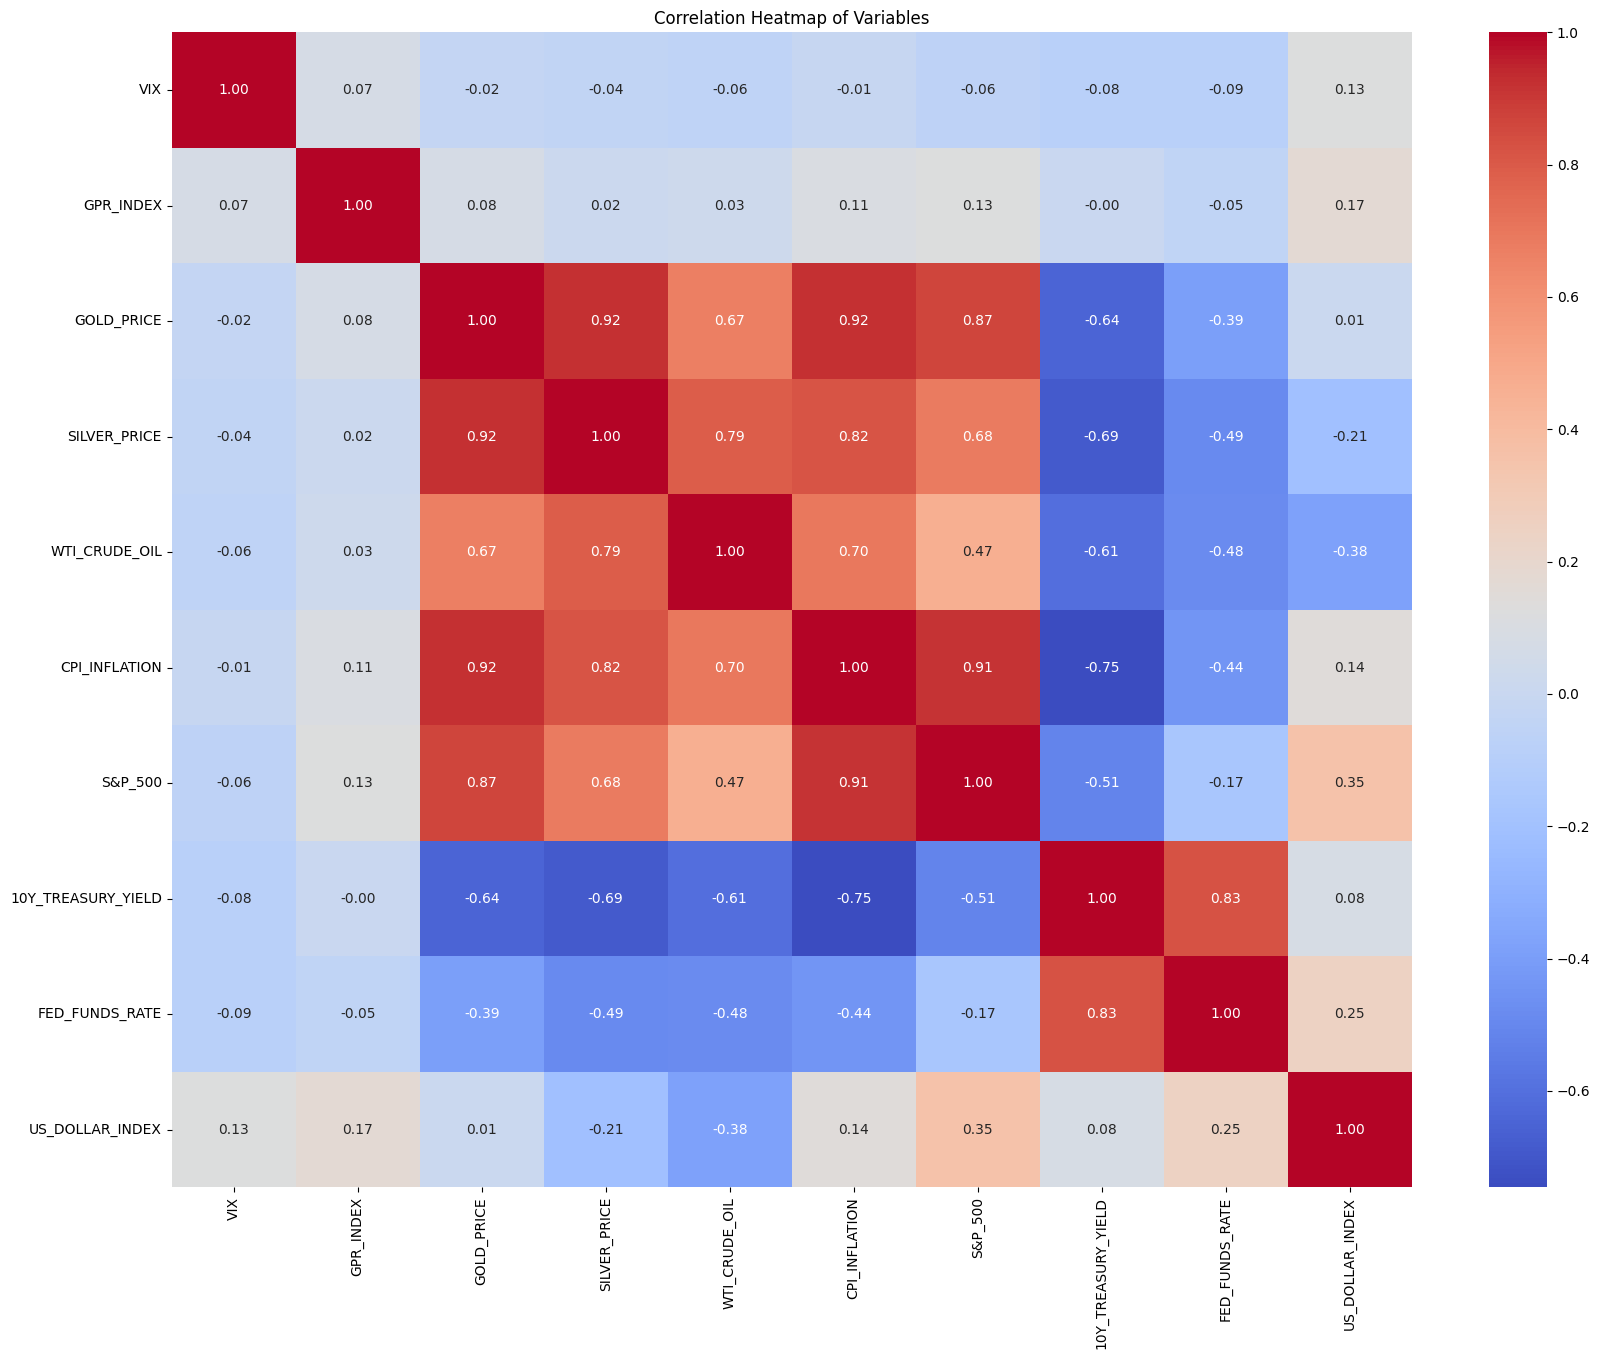

In [ ]:
numerical_df3 = df3[['VIX', 'GPR_INDEX','GOLD_PRICE','SILVER_PRICE','WTI_CRUDE_OIL','CPI_INFLATION','S&P_500','10Y_TREASURY_YIELD','FED_FUNDS_RATE','US_DOLLAR_INDEX']]

corr_matrix = numerical_df3.corr()
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 15))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap of Variables')
plt.show()

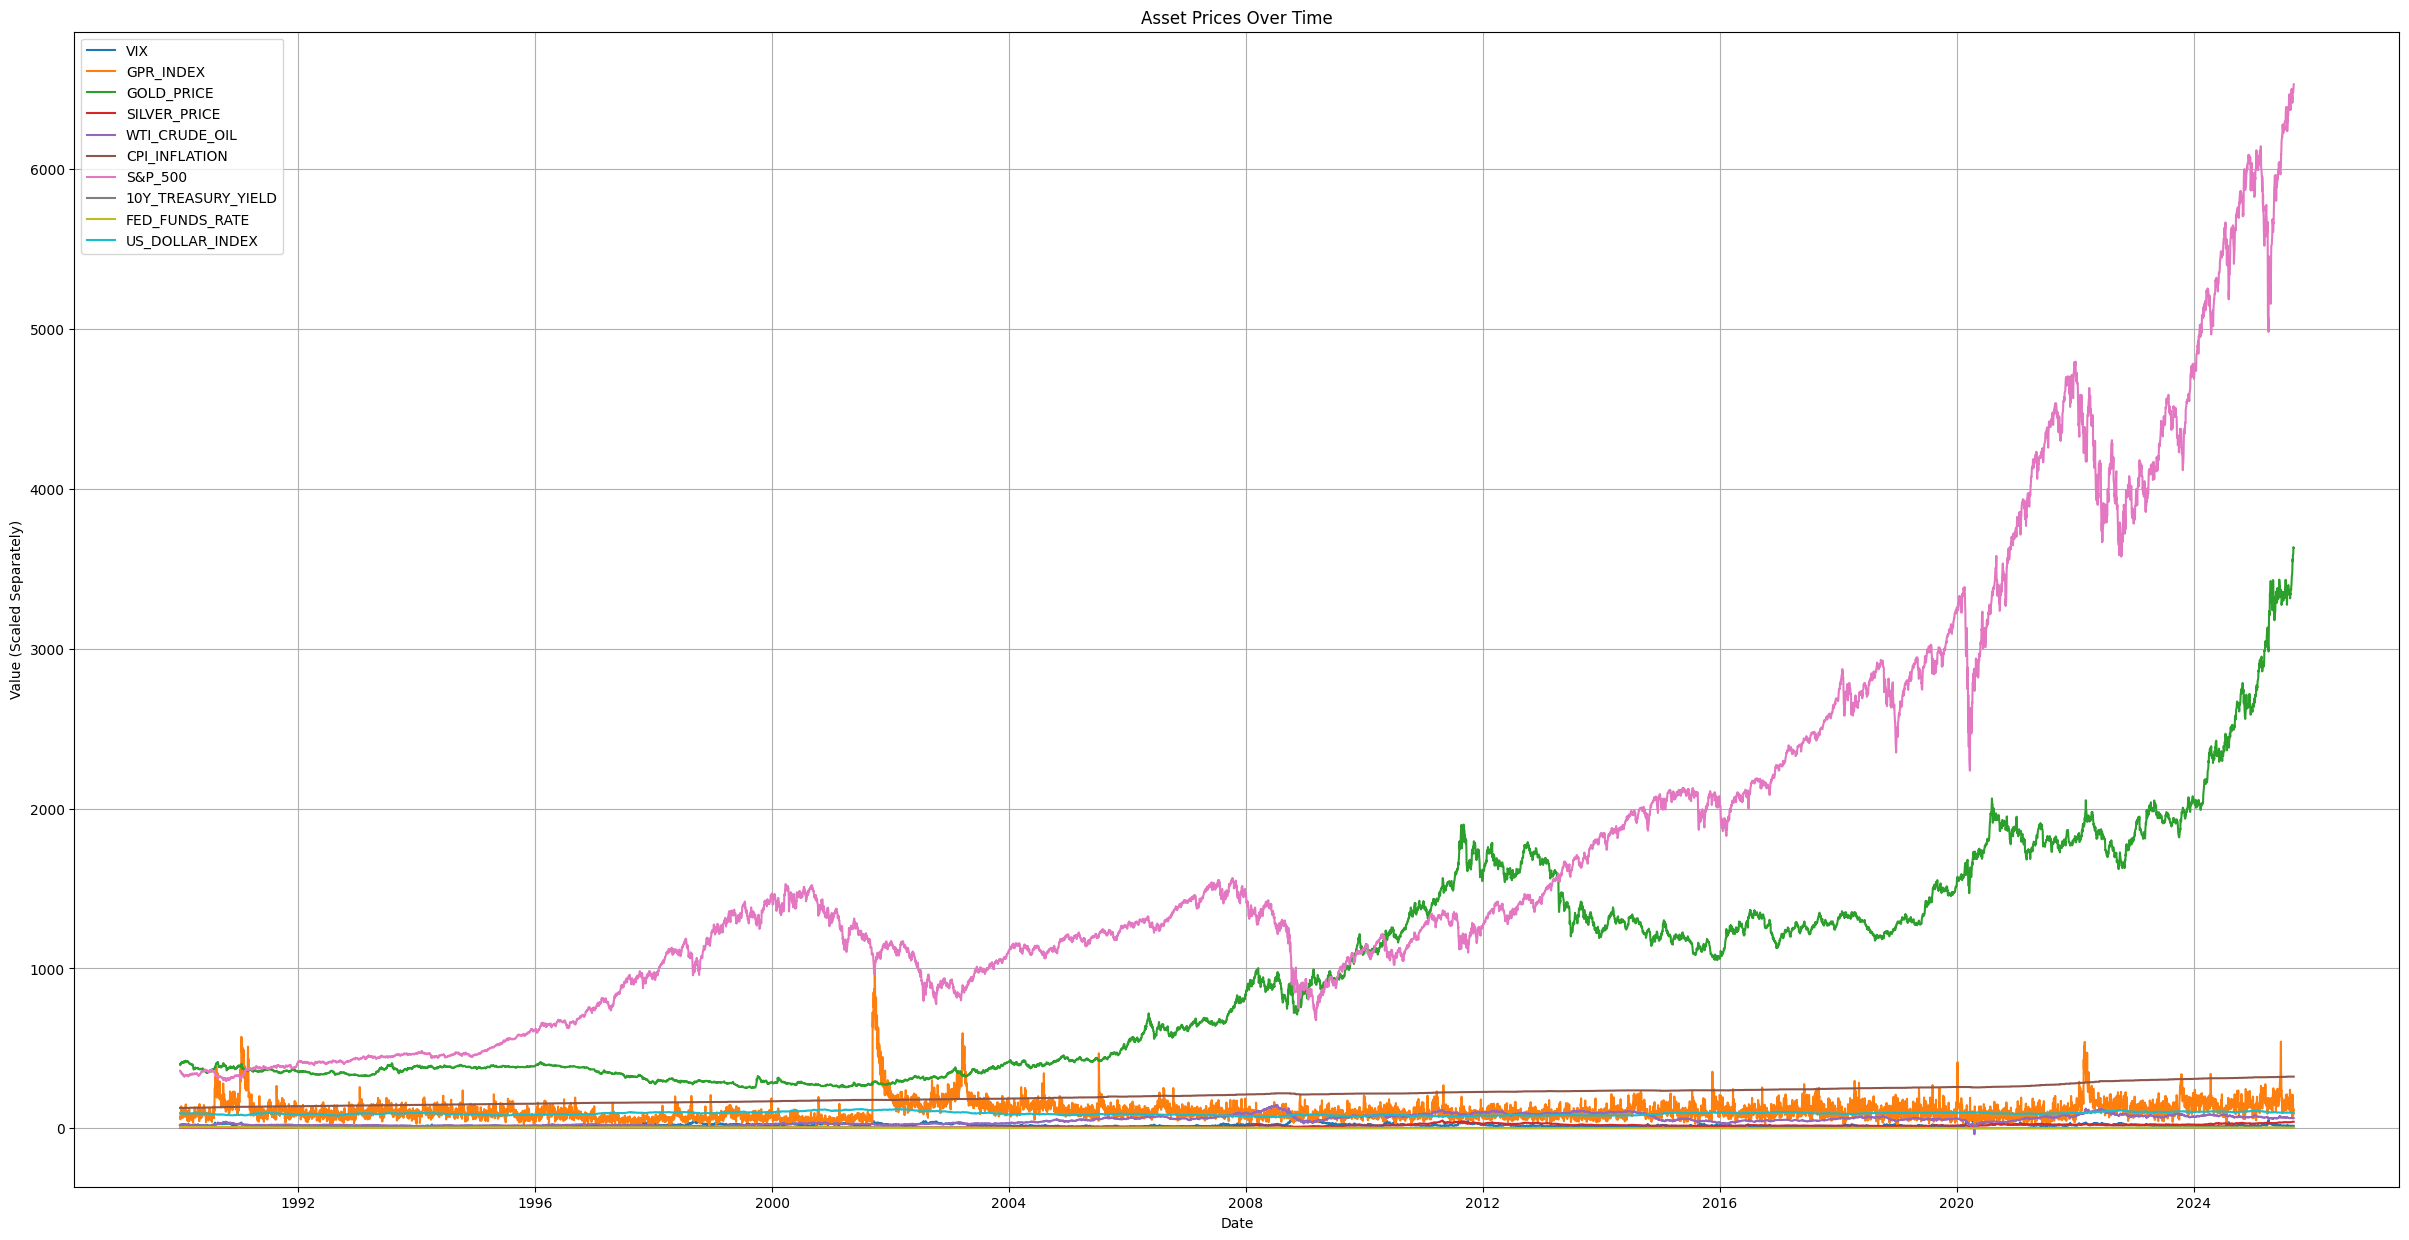

In [ ]:
import matplotlib.pyplot as plt
x_axis = df3['DATE']
columns_to_plot = ['GOLD_PRICE', 'SILVER_PRICE', 'S&P_500', 'WTI_CRUDE_OIL']
plt.figure(figsize=(30, 15))
for col in numerical_df3:
    plt.plot(x_axis, df3[col], label=col)
plt.title('Asset Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Value (Scaled Separately)')
plt.legend()
plt.grid(True)
plt.show()

Optional - I am doing this to understand Simpson's Paradox and get the extra credit available

In [ ]:
import pandas as pd
df_0 = pd.read_csv("/content/berkeley.csv")

In [ ]:
print(df_0.head(10))
df_0.shape

   Year  Major Sex Admission
0  1973      C   F  Rejected
1  1973      B   M  Accepted
2  1973  Other   F  Accepted
3  1973  Other   M  Accepted
4  1973  Other   M  Rejected
5  1973  Other   M  Rejected
6  1973      F   F  Accepted
7  1973  Other   M  Accepted
8  1973  Other   M  Rejected
9  1973      A   M  Accepted


(12763, 4)

In [ ]:
Male_count = df_0[df_0['Sex'] == 'M']['Sex'].value_counts()
print(Male_count)
Female_count = df_0[df_0['Sex'] == 'F']['Sex'].value_counts()
print(Female_count)

Sex
M    8442
Name: count, dtype: int64
Sex
F    4321
Name: count, dtype: int64


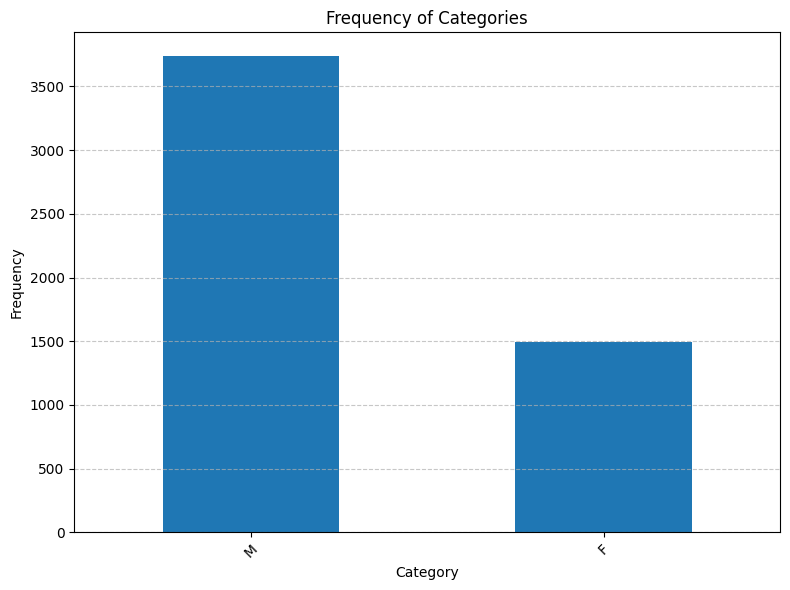

Sex
M    3738
F    1494
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt

category_counts = df_0[df_0['Admission'] == 'Accepted']['Sex'].value_counts()
plt.figure(figsize=(8, 6))
category_counts.plot(kind='bar')
plt.title('Frequency of Categories')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print(category_counts)

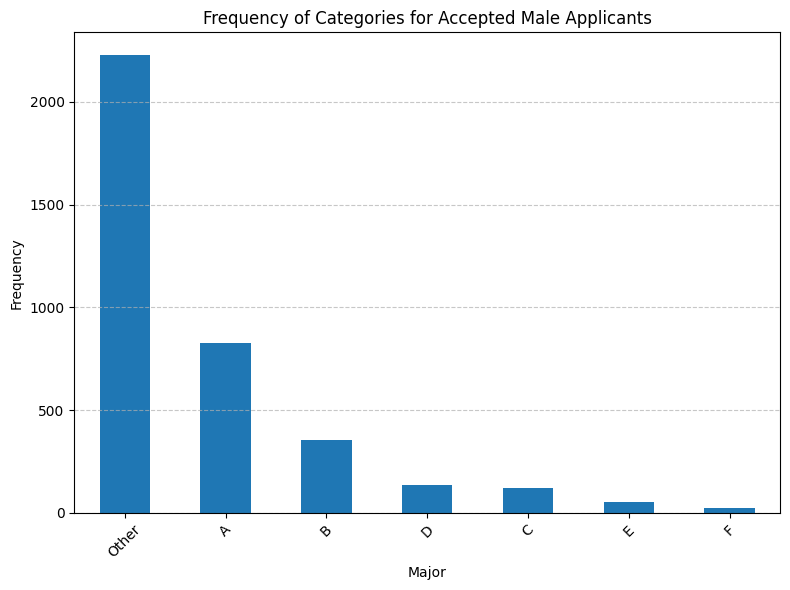

In [ ]:
import matplotlib.pyplot as plt
category_counts = df_0[(df_0['Admission'] == 'Accepted') & (df_0['Sex'] == 'M')]['Major'].value_counts()
plt.figure(figsize=(8, 6))
category_counts.plot(kind='bar')
plt.title('Frequency of Categories for Accepted Male Applicants')
plt.xlabel('Major')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

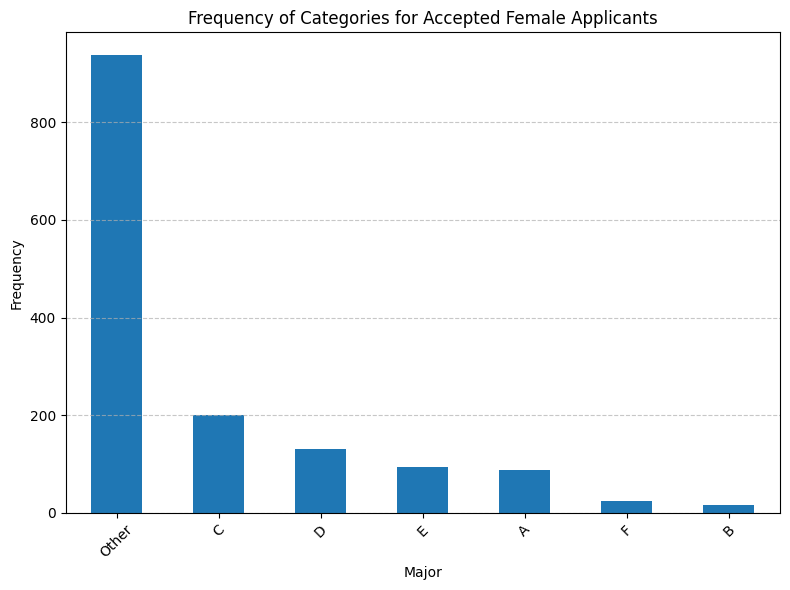

In [ ]:
import matplotlib.pyplot as plt
category_counts = df_0[(df_0['Admission'] == 'Accepted') & (df_0['Sex'] == 'F')]['Major'].value_counts()
plt.figure(figsize=(8, 6))
category_counts.plot(kind='bar')
plt.title('Frequency of Categories for Accepted Female Applicants')
plt.xlabel('Major')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

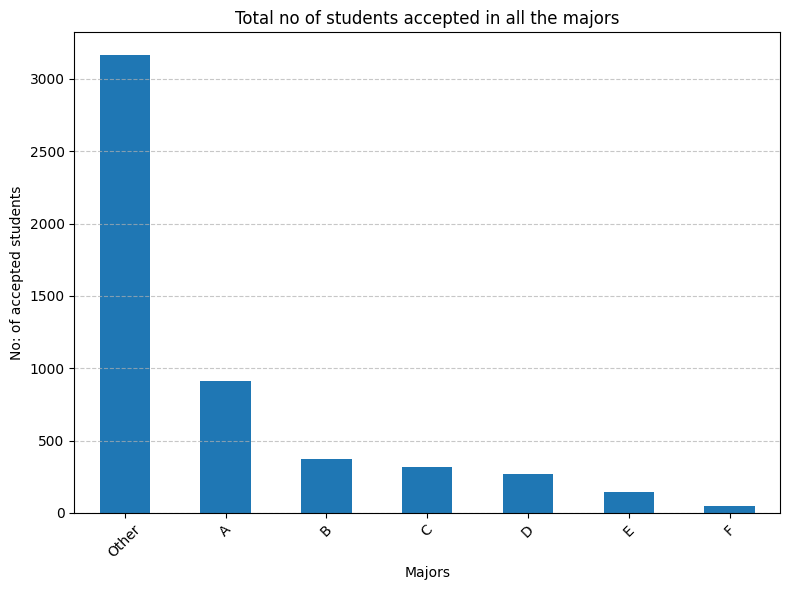

In [ ]:
import matplotlib.pyplot as plt

category_counts = df_0[df_0['Admission'] == 'Accepted']['Major'].value_counts()
plt.figure(figsize=(8, 6))
category_counts.plot(kind='bar')
plt.title('Total no of students accepted in all the majors')
plt.xlabel('Majors')
plt.ylabel('No: of accepted students')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

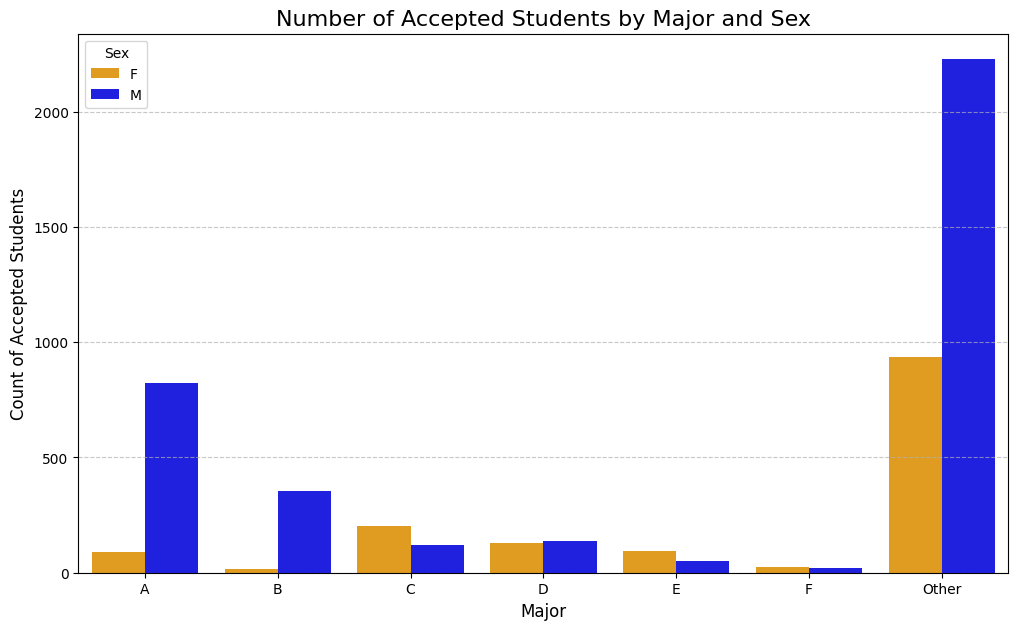

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

accepted_df = df_0[df_0['Admission'] == 'Accepted'].copy()

plot_df = accepted_df.groupby(['Major', 'Sex']).size().reset_index(name='Count')

plt.figure(figsize=(12, 7))
sns.barplot(
    data=plot_df,
    x='Major',
    y='Count',
    hue='Sex',
    order=['A', 'B', 'C', 'D', 'E', 'F', 'Other'],
    palette={'M': 'blue', 'F': 'orange'}
)

plt.title('Number of Accepted Students by Major and Sex', fontsize=16)
plt.xlabel('Major', fontsize=12)
plt.ylabel('Count of Accepted Students', fontsize=12)
plt.legend(title='Sex')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig('accepted_students_by_major_gender_manual.png', dpi=300)

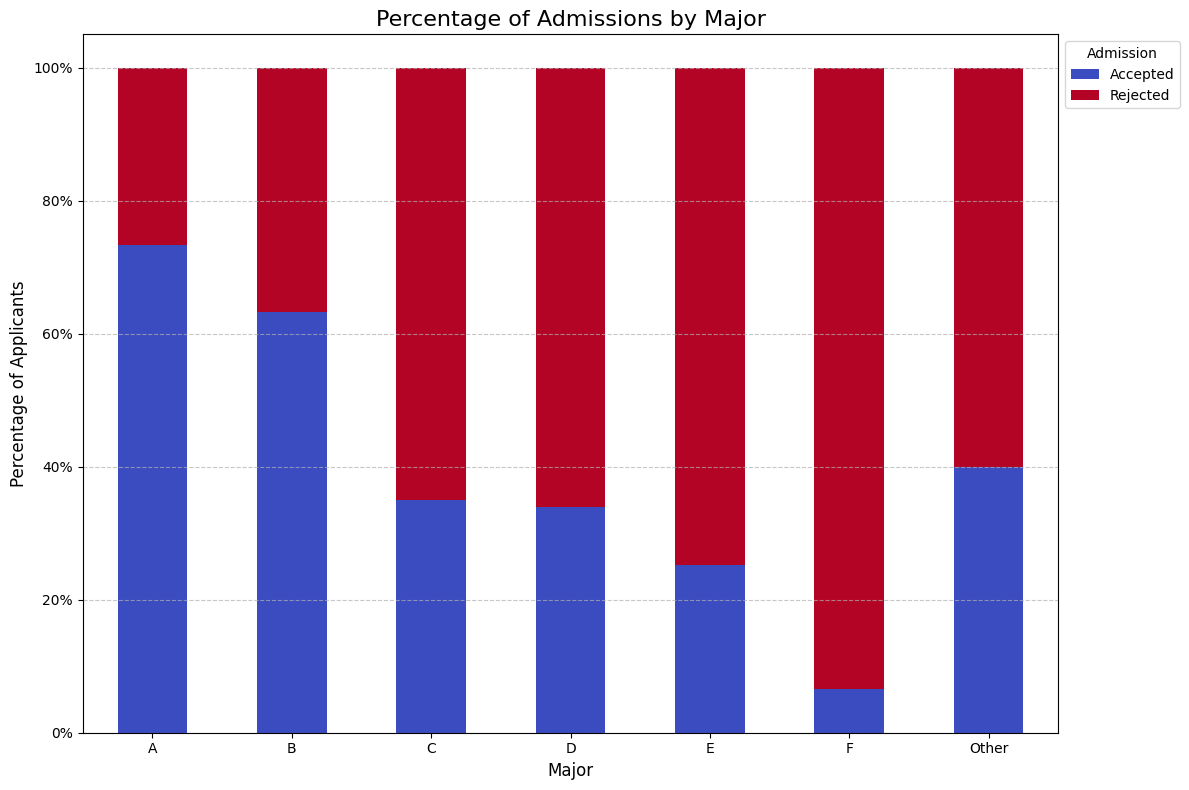

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plot_df = df_0.groupby(['Major', 'Admission']).size().reset_index(name='Count')

pivot_df = plot_df.pivot(index='Major', columns='Admission', values='Count')


pivot_df = pivot_df.reindex(['A', 'B', 'C', 'D', 'E', 'F', 'Other'])

normalized_df = pivot_df.div(pivot_df.sum(axis=1), axis=0)

ax = normalized_df.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 8),
    colormap='coolwarm'
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.title('Percentage of Admissions by Major', fontsize=16)
plt.xlabel('Major', fontsize=12)
plt.ylabel('Percentage of Applicants', fontsize=12)

plt.xticks(rotation=0)

plt.legend(title='Admission', loc='upper left', bbox_to_anchor=(1, 1))

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('admission_percentage_by_major.png', dpi=300)

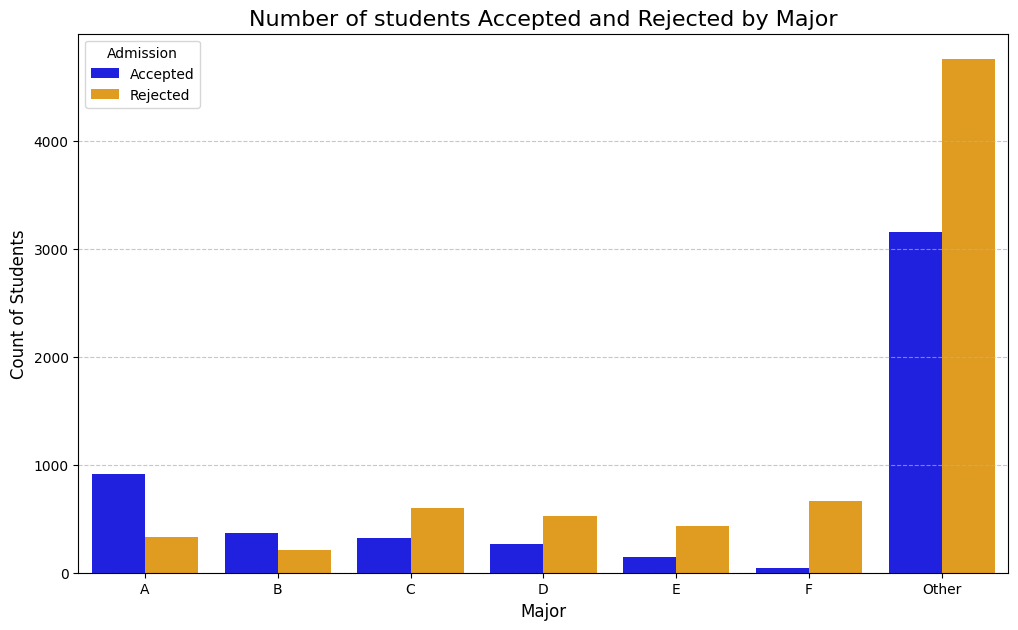

In [ ]:
import pandas as pd
import seaborn as sns

plot_df = df_0.groupby(['Major', 'Admission']).size().reset_index(name='Count')

plt.figure(figsize=(12, 7))
sns.barplot(
    data=plot_df,
    x='Major',
    y='Count',
    hue='Admission',
    order=['A', 'B', 'C', 'D', 'E', 'F', 'Other'],
    palette={'Accepted': 'blue', 'Rejected': 'orange'}
)

plt.title('Number of students Accepted and Rejected by Major', fontsize=16)
plt.xlabel('Major', fontsize=12)
plt.ylabel('Count of Students', fontsize=12)
# plt.legend(title='Sex')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig('accepted_students_by_major_gender_manual.png', dpi=300)

* The environment here is that there are 12736 who applied to UC berkley for the Majors of : A,B,C,D,E,F,Others
* In Total 8442 Men applied for all the Majors and 3738 of them got selected in Uc Berkely, with the % of acceptance for male being 44.27%
* In Total 4321 Female applied for all the Majors and 1494 of them got selected in Uc Berkely, with the % of acceptance for male being 34.57%
* In general, It concludes that Men were more successful in getting into UC Berkely
* But when we see seperately  , particularly in which major the Male and Female students got selected in, it shows us that Men Mostly got selected in easier departments while most students who got selected in the difficult departments were Female.
* Females were higher in number for 4 of the toughest departments, Whereas men were higher for the 3 easiest departement in terms of acceptance percentage.
* It's all because of the lurking variable of 'Major', aka Confounder variable, where getting into one of the few in difficult departments were considered more succesful rather than being many many in a Major of higher acceptance. But that logic was unseen when seen as a whole for total acceptance and rejection. And That's the Sympson's Paradox Here.

**7.**
* Yes I, do trust this data because, the finding's are kind of related to the common notion that when there is inflation the price of GOLD/SILVER increases because it preserves the value in comparison to the depreceating value of the currencies in the period of inflation and the my initial assumption of GPR being not enough to understand the behaviour of the "Safe-haven assets"  was also true. Basically it's data is being true to the financial theories of gold/silver.

**8.**
* It did affect my hypothesis.
* Because I thought GPR will have some relation to the prices which was part 1, but it seems to be irrelevant, but the hypothesis dosen't change much because now it goes from 2->1 instead of 1->2 in my hypothesis, i.e. the 2nd part was about the hidden regimes.
* It's evident that GPR and GOLD/SILVER prices are very weakly correlated and GOLD/SILVER prices are positively correlated with CPI, S&P_500,WTI_CRUDE_OIL ( CPI > S&P_500 > WTI_CRUDE_OIL in the respective strength order). and I would like to Classify the regimes and see if GPR makes some sense after the classification.

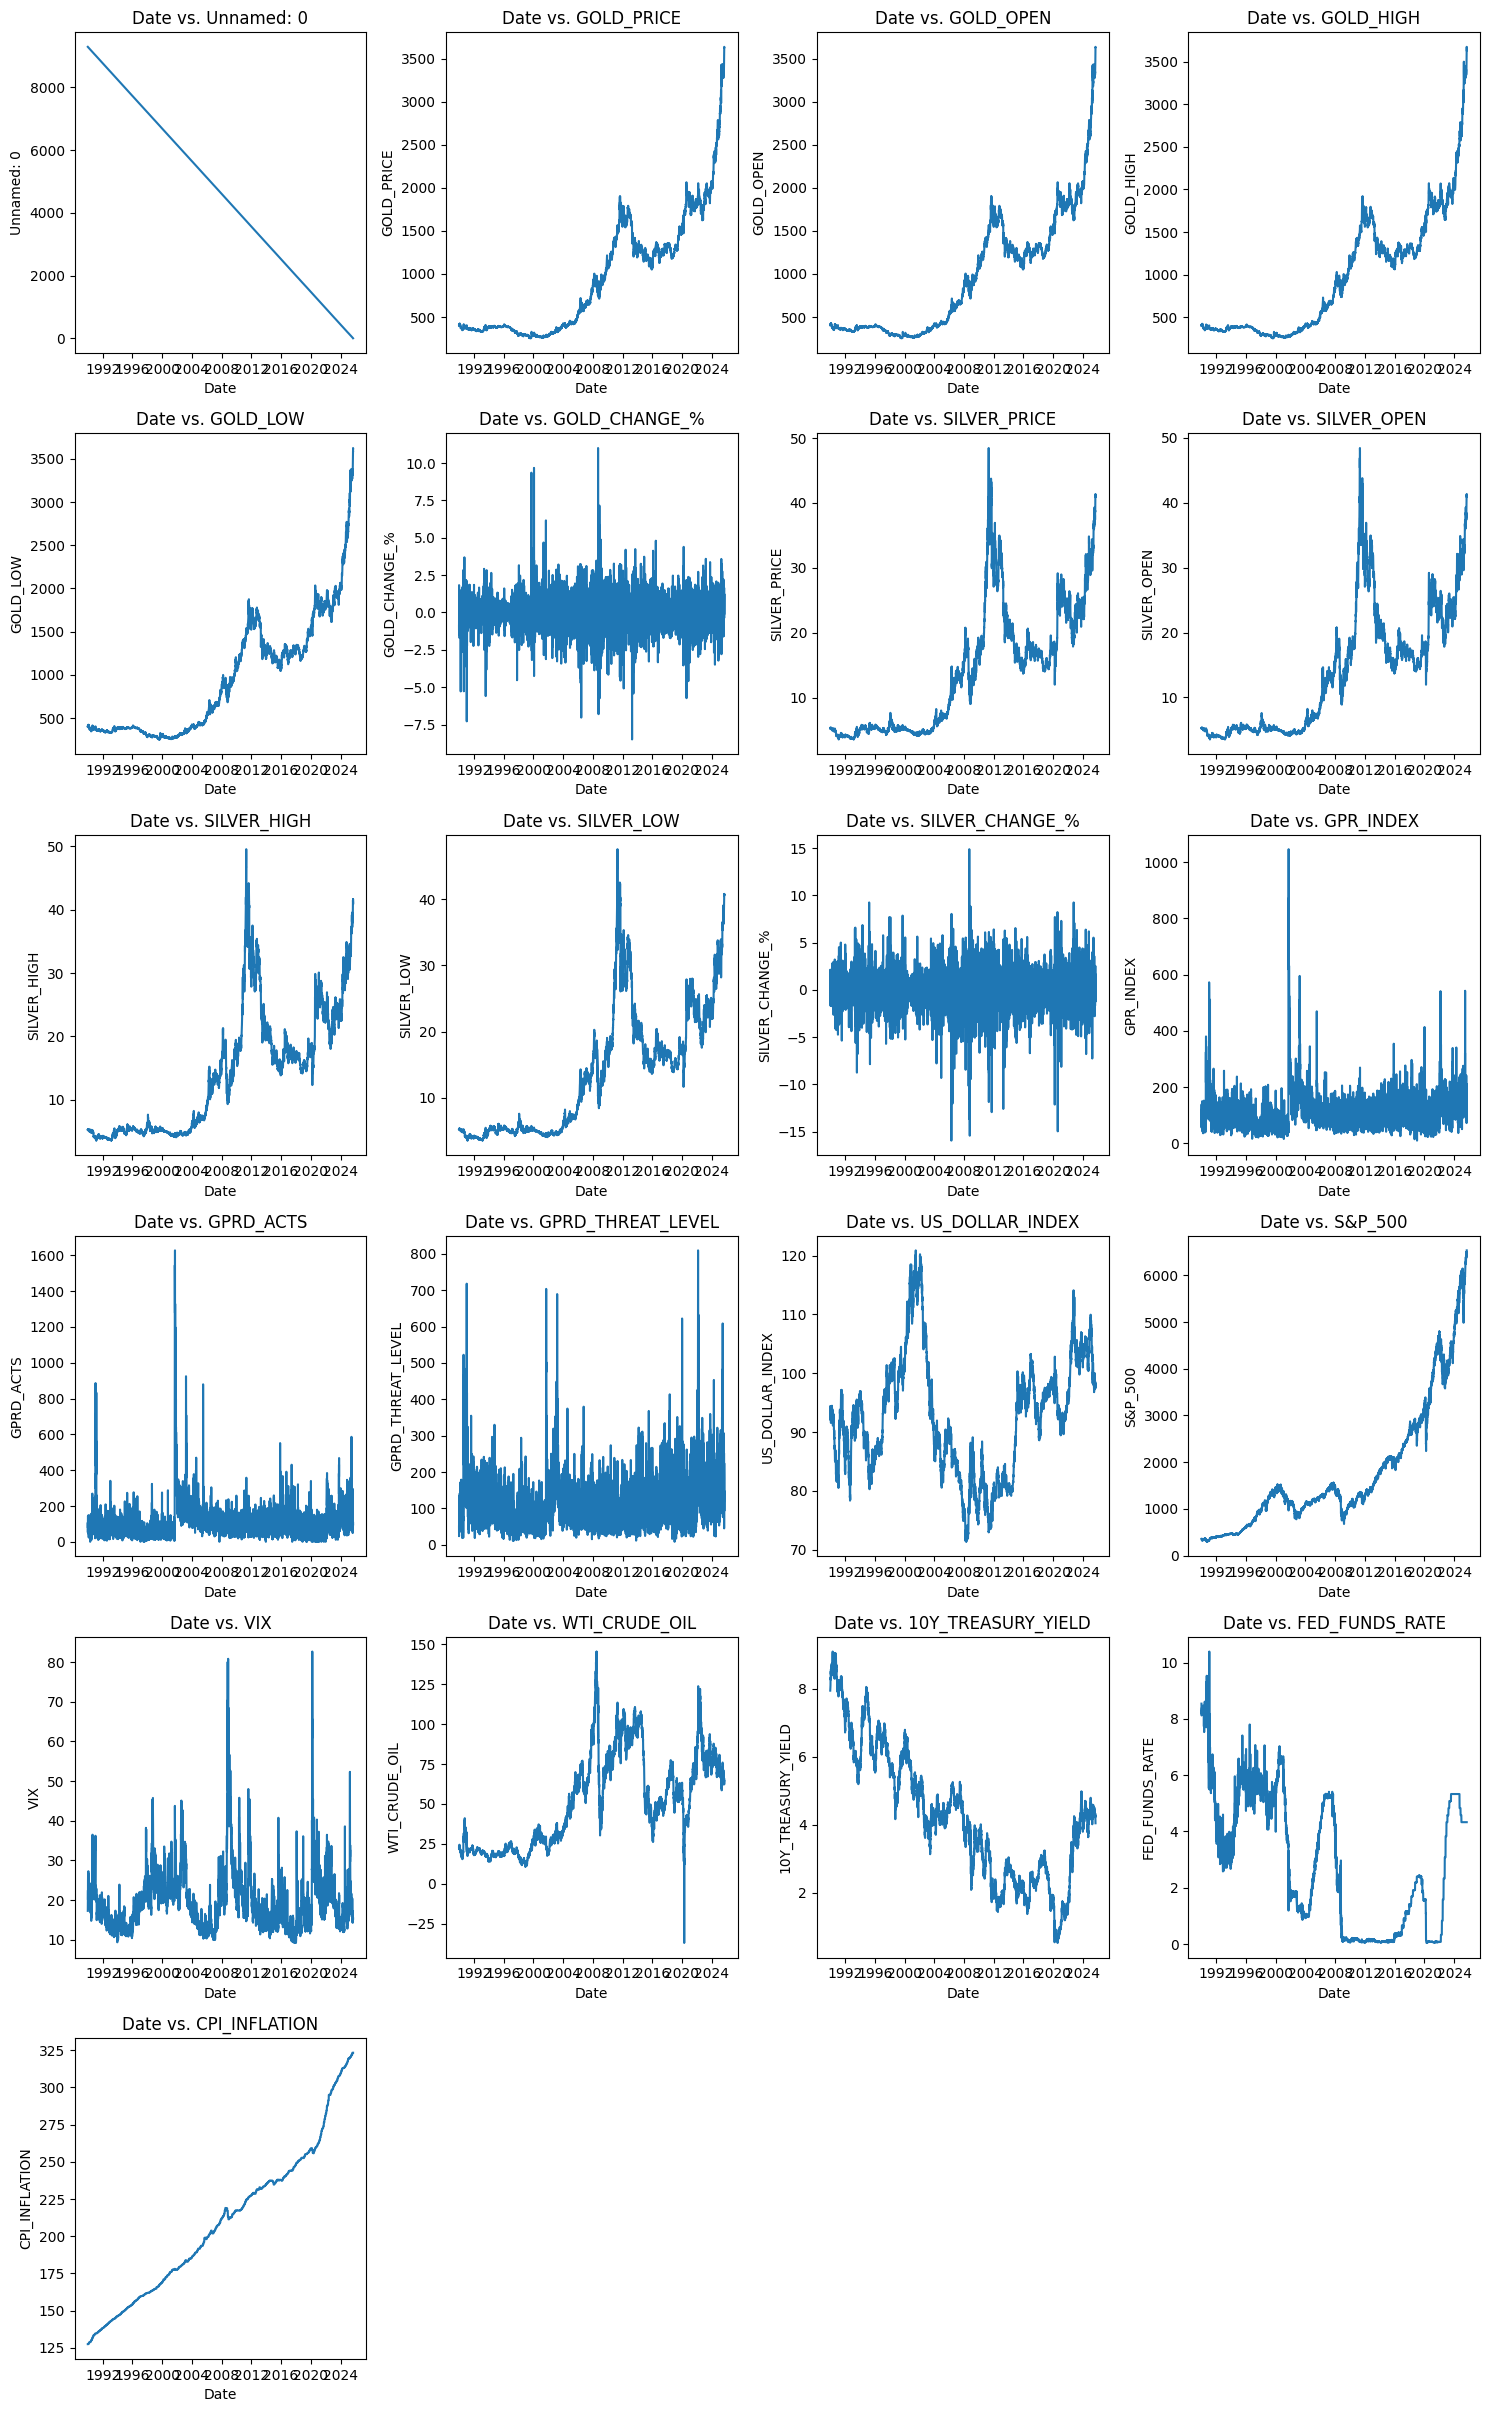

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

numerical_cols = df3.select_dtypes(include=np.number).columns
n_cols = len(numerical_cols)
n_rows = (n_cols + 3)

plt.figure(figsize=(15, n_rows * 4))
for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, 4, i + 1)
    plt.plot(df3['DATE'], df3[f'{col}'])
    plt.title(f'Date vs. {col}')
    plt.xlabel('Date')
    plt.ylabel(f'{col}')

plt.tight_layout()
plt.show()

Log Transformation is done below


In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)
print(df3.head(1))

      Unnamed: 0       DATE  GOLD_PRICE  GOLD_OPEN  GOLD_HIGH  GOLD_LOW  \
9290        9290 1990-01-02      399.45     403.85     399.45    399.45   

      GOLD_CHANGE_%  SILVER_PRICE  SILVER_OPEN  SILVER_HIGH  SILVER_LOW  \
9290          -0.89          5.19         5.18         5.19        5.18   

      SILVER_CHANGE_%  GPR_INDEX  GPRD_ACTS  GPRD_THREAT_LEVEL EVENT  \
9290            -0.57      71.49      83.15              49.54   NaN   

      US_DOLLAR_INDEX     S&P_500    VIX  WTI_CRUDE_OIL  10Y_TREASURY_YIELD  \
9290        94.290001  359.690002  17.24          22.88                7.94   

      FED_FUNDS_RATE  CPI_INFLATION  
9290            8.54          127.5  


In [ ]:
df3.dtypes

,0
Unnamed: 0,int64
DATE,datetime64[ns]
GOLD_PRICE,float64
GOLD_OPEN,float64
GOLD_HIGH,float64
GOLD_LOW,float64
GOLD_CHANGE_%,float64
SILVER_PRICE,float64
SILVER_OPEN,float64
SILVER_HIGH,float64


In [ ]:
print(numerical_cols)

Index(['Unnamed: 0', 'GOLD_PRICE', 'GOLD_OPEN', 'GOLD_HIGH', 'GOLD_LOW',
       'GOLD_CHANGE_%', 'SILVER_PRICE', 'SILVER_OPEN', 'SILVER_HIGH',
       'SILVER_LOW', 'SILVER_CHANGE_%', 'GPR_INDEX', 'GPRD_ACTS',
       'GPRD_THREAT_LEVEL', 'US_DOLLAR_INDEX', 'S&P_500', 'VIX',
       'WTI_CRUDE_OIL', '10Y_TREASURY_YIELD', 'FED_FUNDS_RATE',
       'CPI_INFLATION'],
      dtype='object')


In [ ]:
print(df3[['FED_FUNDS_RATE', 'VIX', 'GPR_INDEX', 'GPRD_ACTS','GPRD_THREAT_LEVEL']])

      FED_FUNDS_RATE        VIX  GPR_INDEX  GPRD_ACTS  GPRD_THREAT_LEVEL
9290            8.54  17.240000      71.49      83.15              49.54
9289            8.37  18.190001      75.41     107.39              35.83
9288            8.29  19.219999      56.09      83.87              23.32
9287            8.20  20.110001      63.85      52.42              74.95
9286            8.27  20.260000     102.84      86.34              99.02
...              ...        ...        ...        ...                ...
4               4.33  15.180000     166.42     110.61             224.05
3               4.33  15.180000      83.51     111.00              92.59
2               4.33  15.110000     117.26      97.42             146.26
1               4.33  15.040000     117.26      97.42             146.26
0               4.33  15.350000     117.26      97.42             146.26

[9291 rows x 5 columns]


In [ ]:
print(df3[['VIX', 'GPR_INDEX', 'GPRD_ACTS','GPRD_THREAT_LEVEL','FED_FUNDS_RATE']])

            VIX  GPR_INDEX  GPRD_ACTS  GPRD_THREAT_LEVEL  FED_FUNDS_RATE
9290  17.240000      71.49      83.15              49.54            8.54
9289  18.190001      75.41     107.39              35.83            8.37
9288  19.219999      56.09      83.87              23.32            8.29
9287  20.110001      63.85      52.42              74.95            8.20
9286  20.260000     102.84      86.34              99.02            8.27
...         ...        ...        ...                ...             ...
4     15.180000     166.42     110.61             224.05            4.33
3     15.180000      83.51     111.00              92.59            4.33
2     15.110000     117.26      97.42             146.26            4.33
1     15.040000     117.26      97.42             146.26            4.33
0     15.350000     117.26      97.42             146.26            4.33

[9291 rows x 5 columns]


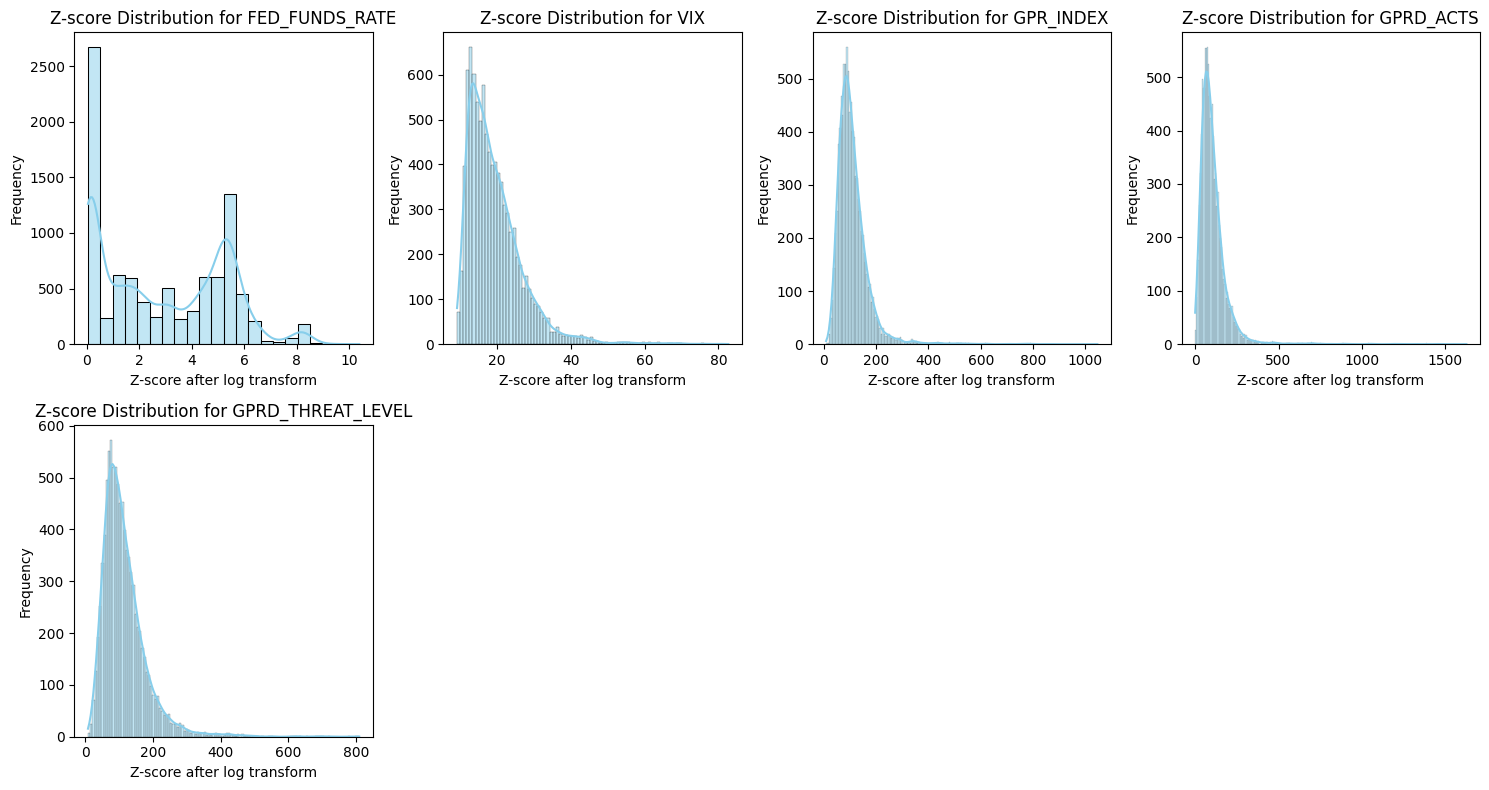

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
columns_to_log = ['FED_FUNDS_RATE', 'VIX', 'GPR_INDEX', 'GPRD_ACTS','GPRD_THREAT_LEVEL']

n_cols = len(columns_to_log)
n_rows = (n_cols + 3) // 4

plt.figure(figsize=(15, n_rows * 4))

for i, col in enumerate(columns_to_log):
    plt.subplot(n_rows, 4, i + 1)
    sns.histplot(df3[f'{col}'], kde=True, color='skyblue')
    plt.title(f'Z-score Distribution for {col}')
    plt.xlabel('Z-score after log transform')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

**Part-4**

In [ ]:
import pandas as pd
df4 = pd.read_csv("/content/merged_final_2_merged_final_2.csv")

**2.**
* The ML task that is presented by my hypothesis is clustering and it is unsupervied learning.
* And This is a Unsupervised type of Machine Learning, because there is no labels present to train the model and in fact we are using the model to cluster the dataset into clusters that in turn could be labelled under few recognizable labels.
* **In High Level**, we suspect that the markets have hidden "moods", but we don't know what they are and when they happen. We are trying to cluster them with the help of k-means , to see if the prices of the safe-Haven assests (Gold,Silver) are having some pattern based on the clusters formed. **Basically trying to find how the prices of the safe-Haven assests are affected in each defined cluster.**

In [ ]:
pd.set_option('display.max_columns', None)
df4.head()

,DATE,GOLD_PRICE,GOLD_OPEN,GOLD_HIGH,GOLD_LOW,GOLD_CHANGE_%,SILVER_PRICE,SILVER_OPEN,SILVER_HIGH,SILVER_LOW,SILVER_CHANGE_%,GPR_INDEX,GPRD_ACTS,GPRD_THREAT_LEVEL,EVENT,US_DOLLAR_INDEX,S&P_500,VIX,WTI_CRUDE_OIL,10Y_TREASURY_YIELD,FED_FUNDS_RATE,CPI_INFLATION
0,10/09/2025,"3,630.9","3,633.61","3,634.42","3,620.9",-0.07,40.92,40.89,40.94,40.72,0.09,117.26,97.42,146.26,NaN,97.779999,"6,532.040039063",15.35,64.01,4.04,4.33,323.364
1,09/09/2025,"3,633.61","3,637.1","3,674.75","3,625.33",-0.06,40.89,41.34,41.50,40.77,-1.13,117.26,97.42,146.26,NaN,97.790001,"6,512.609863281",15.04,62.97,4.08,4.33,323.364
2,08/09/2025,"3,635.84","3,586.82","3,646.6","3,579.67",1.24,41.36,41.01,41.68,40.51,1.20,117.26,97.42,146.26,NaN,97.449997,"6,495.149902344",15.11,62.60,4.05,4.33,323.364
3,07/09/2025,"3,591.19","3,592.07","3,596.56","3,586.95",0.12,40.86,41.00,41.01,40.76,-0.34,83.51,111,92.59,NaN,97.769997,"6,481.5",15.18,62.22,4.10,4.33,323.364
4,05/09/2025,"3,586.81","3,547","3,600.33","3,540.05",1.15,41.01,40.69,41.44,40.55,0.76,166.42,110.61,224.05,NaN,97.769997,"6,481.5",15.18,62.22,4.10,4.33,323.364


**3.**
* For Feature engineering :

* I did **feature creation** with 10Y_TREASURY_YIELD and CPI_INFLATION, by subtracting them for getting the REAL_YIELD, which actually give a closer idea of the purchasing power of our investments after accounting for inflation.
* **Feature transformation** for GOLD_PRICE, S&P_500, WTI_CRUDE_OIL,US_DOLLAR_INDEX, for getting the percentage change value. and with SP500_RET and GOLD_RET, i did calculate it's 21-day rolling volataility by taking its standard deviation for every 21 days in a rolling manner. Finally, scaled my input features for k-means too. After the transformation the real value columns were neglected and their transformations were used from then.
* For **feature selection** I have used a correlation heatmap, to find out feature sets that were highly correlated and neglected the ones that are hard to interpret, from the input featuers of the kmeans, and kept the features that were easy to interpret. like for example the VIX_log was kept and SP500_VOL was neglected, and they had a high positive correlation, the two features almost giving the same signals to the model.

* Yes I was able to reduce the from almost 10+ featuers to 5 featuers
* The dimentionality of the dataframe that was used for the Algorithm was (9291, 5)
* The asumptions of the features were that they are roughly symetrically distributed (Gaussian distribution) ,have low multicollineartiy (feature independence) and Homoscedasticity (Equal Variance).
* These were the feature selected for the algorithm : VIX_log, GPR_INDEX_log, REAL_YIELD, USD_RET, SP500_RET. all of these featuers are of continuous values.




In [ ]:
#Log transformation
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

columns_to_log = ['FED_FUNDS_RATE', 'VIX', 'GPR_INDEX', 'GPRD_ACTS','GPRD_THREAT_LEVEL']

# Convert columns to numeric, coercing errors to NaN
for col in columns_to_log:
    df4[col] = pd.to_numeric(df4[col], errors='coerce')

# Apply log transformation to the numeric columns
for col in columns_to_log:
    # Only apply log to non-negative values, as log of zero or negative is undefined
    df4[f'{col}_log'] = np.log(df4[col].replace(0, np.nan)) # Replace 0 with NaN before log

print("Log transformation done.")

Log transformation done.


In [ ]:
# Function to clean and convert to numeric
def clean_numeric_column(series):
    return series.astype(str).str.replace(',', '', regex=False).astype(float)

# Apply cleaning to relevant columns
df4['GOLD_PRICE'] = clean_numeric_column(df4['GOLD_PRICE'])
df4['S&P_500'] = clean_numeric_column(df4['S&P_500'])
df4['WTI_CRUDE_OIL'] = clean_numeric_column(df4['WTI_CRUDE_OIL'])
df4['US_DOLLAR_INDEX'] = clean_numeric_column(df4['US_DOLLAR_INDEX'])

df4['GOLD_RET'] = df4['GOLD_PRICE'].pct_change()
df4['SP500_RET'] = df4['S&P_500'].pct_change()
df4['OIL_RET'] = df4['WTI_CRUDE_OIL'].pct_change()
df4['USD_RET'] = df4['US_DOLLAR_INDEX'].pct_change()

In [ ]:
df4['DATE'] = pd.to_datetime(df4['DATE'], format='%d/%m/%Y')

# Sort the DataFrame by 'DATE' in ascending order
df4 = df4.sort_values(by='DATE', ascending=True).reset_index(drop=True)

print("DataFrame sorted by date (oldest to newest).")
print("Head of DataFrame after sorting:")
display(df4.head())

DataFrame sorted by date (oldest to newest).
Head of DataFrame after sorting:


,DATE,GOLD_PRICE,GOLD_OPEN,GOLD_HIGH,GOLD_LOW,GOLD_CHANGE_%,SILVER_PRICE,SILVER_OPEN,SILVER_HIGH,SILVER_LOW,SILVER_CHANGE_%,GPR_INDEX,GPRD_ACTS,GPRD_THREAT_LEVEL,EVENT,US_DOLLAR_INDEX,S&P_500,VIX,WTI_CRUDE_OIL,10Y_TREASURY_YIELD,FED_FUNDS_RATE,CPI_INFLATION,FED_FUNDS_RATE_log,VIX_log,GPR_INDEX_log,GPRD_ACTS_log,GPRD_THREAT_LEVEL_log,GOLD_RET,SP500_RET,OIL_RET,USD_RET
0,1990-01-02,399.45,403.85,399.45,399.45,-0.89,5.19,5.18,5.19,5.18,-0.57,71.49,83.15,49.54,NaN,94.290001,359.690002,17.240000,22.88,7.94,8.54,127.5,2.144761,2.847232,4.269558,4.420646,3.902780,0.011906,0.002592,-0.039059,-0.001377
1,1990-01-03,394.75,399.6,394.75,394.75,-1.18,5.17,5.17,5.17,5.17,-0.39,75.41,107.39,35.83,NaN,94.419998,358.760010,18.190001,23.81,7.99,8.37,127.5,2.124654,2.900872,4.322940,4.676467,3.578786,-0.010776,0.008688,0.017087,0.020536
2,1990-01-04,399.05,399.45,399.05,399.05,1.09,5.28,5.27,5.28,5.27,2.13,56.09,83.87,23.32,NaN,92.519997,355.670013,19.219999,23.41,7.98,8.29,127.5,2.115050,2.955951,4.026958,4.429268,3.149311,-0.017965,0.009852,0.014738,-0.003554
3,1990-01-05,406.35,407.45,406.35,406.35,1.83,5.33,5.32,5.33,5.32,0.95,63.85,52.42,74.95,NaN,92.849998,352.200012,20.110001,23.07,7.99,8.20,127.5,2.104134,3.001217,4.156537,3.959288,4.316821,0.010570,-0.004494,0.066081,0.008691
4,1990-01-08,402.10,405.75,402.1,402.1,-1.05,5.25,5.24,5.25,5.24,-1.50,102.84,86.34,99.02,NaN,92.050003,353.790009,20.260000,21.64,8.02,8.27,127.5,2.112635,3.008649,4.633174,4.458293,4.595322,-0.008996,0.011927,-0.027416,-0.003248


In [ ]:
df4['SP500_VOL'] = df4['SP500_RET'].rolling(window=21).std()
df4['GOLD_VOL'] = df4['GOLD_RET'].rolling(window=21).std()

In [ ]:
df4['REAL_YIELD'] = df4['10Y_TREASURY_YIELD'] - df4['CPI_INFLATION']
print(df4['REAL_YIELD'])
df4.head()

0      -119.560
1      -119.510
2      -119.520
3      -119.510
4      -119.480
         ...   
9286   -319.264
9287   -319.264
9288   -319.314
9289   -319.284
9290   -319.324
Name: REAL_YIELD, Length: 9291, dtype: float64


,DATE,GOLD_PRICE,GOLD_OPEN,GOLD_HIGH,GOLD_LOW,GOLD_CHANGE_%,SILVER_PRICE,SILVER_OPEN,SILVER_HIGH,SILVER_LOW,SILVER_CHANGE_%,GPR_INDEX,GPRD_ACTS,GPRD_THREAT_LEVEL,EVENT,US_DOLLAR_INDEX,S&P_500,VIX,WTI_CRUDE_OIL,10Y_TREASURY_YIELD,FED_FUNDS_RATE,CPI_INFLATION,FED_FUNDS_RATE_log,VIX_log,GPR_INDEX_log,GPRD_ACTS_log,GPRD_THREAT_LEVEL_log,GOLD_RET,SP500_RET,OIL_RET,USD_RET,SP500_VOL,GOLD_VOL,REAL_YIELD
0,1990-01-02,399.45,403.85,399.45,399.45,-0.89,5.19,5.18,5.19,5.18,-0.57,71.49,83.15,49.54,NaN,94.290001,359.690002,17.240000,22.88,7.94,8.54,127.5,2.144761,2.847232,4.269558,4.420646,3.902780,0.011906,0.002592,-0.039059,-0.001377,NaN,NaN,-119.56
1,1990-01-03,394.75,399.6,394.75,394.75,-1.18,5.17,5.17,5.17,5.17,-0.39,75.41,107.39,35.83,NaN,94.419998,358.760010,18.190001,23.81,7.99,8.37,127.5,2.124654,2.900872,4.322940,4.676467,3.578786,-0.010776,0.008688,0.017087,0.020536,NaN,NaN,-119.51
2,1990-01-04,399.05,399.45,399.05,399.05,1.09,5.28,5.27,5.28,5.27,2.13,56.09,83.87,23.32,NaN,92.519997,355.670013,19.219999,23.41,7.98,8.29,127.5,2.115050,2.955951,4.026958,4.429268,3.149311,-0.017965,0.009852,0.014738,-0.003554,NaN,NaN,-119.52
3,1990-01-05,406.35,407.45,406.35,406.35,1.83,5.33,5.32,5.33,5.32,0.95,63.85,52.42,74.95,NaN,92.849998,352.200012,20.110001,23.07,7.99,8.20,127.5,2.104134,3.001217,4.156537,3.959288,4.316821,0.010570,-0.004494,0.066081,0.008691,NaN,NaN,-119.51
4,1990-01-08,402.10,405.75,402.1,402.1,-1.05,5.25,5.24,5.25,5.24,-1.50,102.84,86.34,99.02,NaN,92.050003,353.790009,20.260000,21.64,8.02,8.27,127.5,2.112635,3.008649,4.633174,4.458293,4.595322,-0.008996,0.011927,-0.027416,-0.003248,NaN,NaN,-119.48


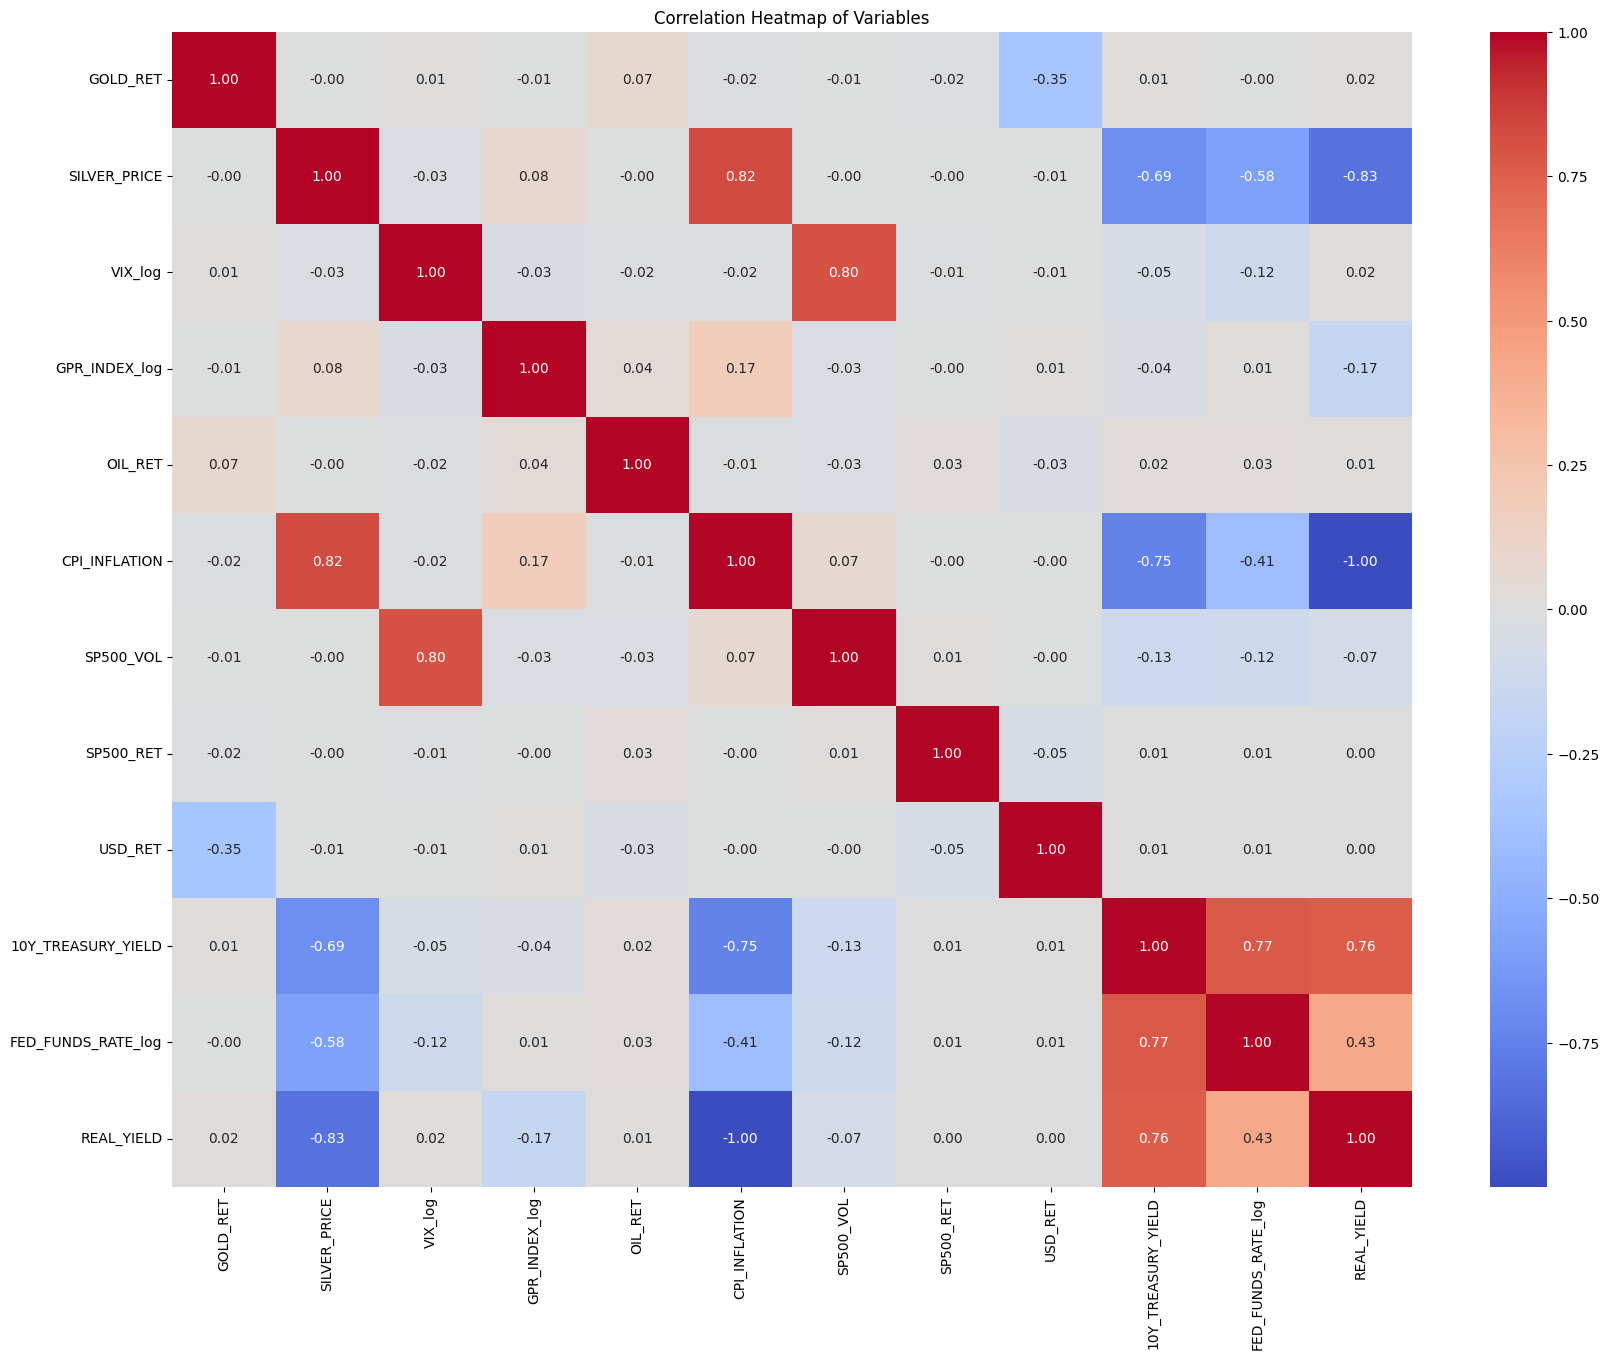

In [ ]:
numerical_df4 = df4[['GOLD_RET','SILVER_PRICE','VIX_log', 'GPR_INDEX_log','OIL_RET','CPI_INFLATION','SP500_VOL','SP500_RET','USD_RET','10Y_TREASURY_YIELD','FED_FUNDS_RATE_log','REAL_YIELD']]

corr_matrix = numerical_df4.corr()
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 15))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap of Variables')
plt.show()

**4.**
* The selected algorithm is k-means.
* the assumptions made by the algorithm were:
  * it is assumed that the featuers are independent and scaled similarly
  * it also assumes that there no extreme outliers
* Issue to watch out here is, that there is a possibility that the algorithm can get stuck in local minima(bad starting points) and also may suffer from the "Curse of dimentionality" if too many featuers are used.
* to mitigate that n_init is initiaized to 10, such that the algo is runned 10 times to get the better shot to be out of the local minima trap, and the number of features is strictly selected to be 5, instead of a higher number.
* Basically, Supervised learning for this dataset was not possible because we did not have any uselful labels, therefore unsupervised learning was the only option and k-means was a simple unsupervised algo that does clustering in a understandable way, as well as there are not many familiar algorithms that do clustering and that makes kmeans a good enough algo for the ML task of clustering.

In [ ]:
featuers_for_kmeans = ['VIX_log','GPR_INDEX_log','REAL_YIELD','USD_RET','SP500_RET']
X_final = df4[featuers_for_kmeans].copy()
X_final = X_final.replace([np.inf, -np.inf], np.nan).dropna()
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)

In [ ]:
featuers_for_kmeans = df4[['VIX_log','GPR_INDEX_log','REAL_YIELD','USD_RET','SP500_RET']]
print(featuers_for_kmeans.shape)
print(featuers_for_kmeans)

(9291, 5)
       VIX_log  GPR_INDEX_log  REAL_YIELD   USD_RET  SP500_RET
0     2.847232       4.269558    -119.560 -0.001377   0.002592
1     2.900872       4.322940    -119.510  0.020536   0.008688
2     2.955951       4.026958    -119.520 -0.003554   0.009852
3     3.001217       4.156537    -119.510  0.008691  -0.004494
4     3.008649       4.633174    -119.480 -0.003248   0.011927
...        ...            ...         ...       ...        ...
9286  2.719979       5.114515    -319.264  0.000000   0.000000
9287  2.719979       4.424966    -319.264  0.003284  -0.002102
9288  2.715357       4.764394    -319.314 -0.003477  -0.002681
9289  2.710713       4.764394    -319.284  0.000102  -0.002975
9290  2.731115       4.764394    -319.324       NaN        NaN

[9291 rows x 5 columns]


**5.**
* The Hyperparameter used are :
  - k (the number of clusters), it was chosen with the help of silhouette scores, the smallest k with the highest silhouette score was chosen.
  - n_init (the number of times the kmeans algo runs with different random starting centroids.), this was chosen on the basis of common best practices of kmeans.


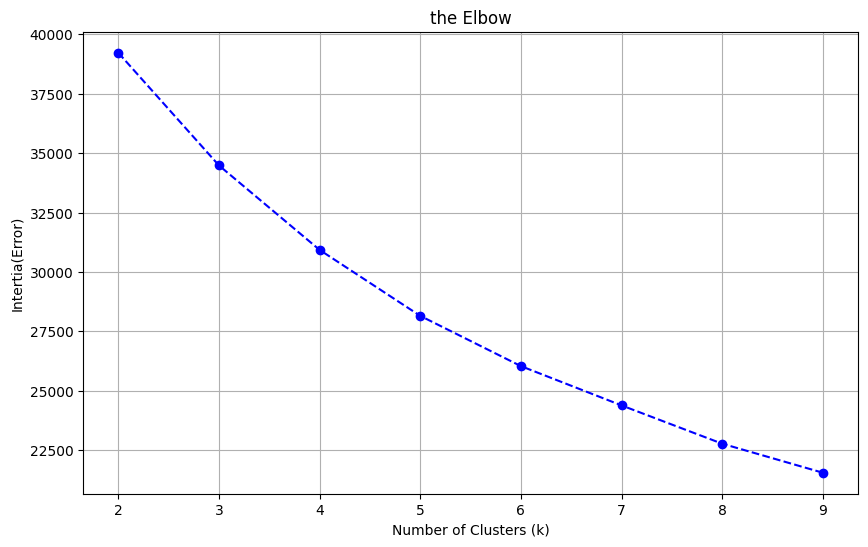

Silhoutte scores:
k=2: 0.1678
k=3: 0.1671
k=4: 0.1726
k=5: 0.1727
k=6: 0.1699
k=7: 0.1725
k=8: 0.1672
k=9: 0.1700
k=10: 0.1646


In [ ]:
from matplotlib.lines import lineStyles
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
intertia = []
K_range = range(2, 10)
for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    intertia.append(model.inertia_)
plt.figure(figsize=(10,6))
plt.plot(K_range,intertia,marker='o', linestyle='--', color='b')
plt.title('the Elbow')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Intertia(Error)')
plt.grid(True)
plt.show()

print("Silhoutte scores:")
for k in range(2,11):
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  labels = kmeans.fit_predict(X_scaled)
  score = silhouette_score(X_scaled, labels)
  print(f"k={k}: {score:.4f}")

**7. Run ML code :**

In [ ]:
optimal_k = 4
final_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = final_model.fit_predict(X_scaled)
regime_series = pd.Series(cluster_labels, index=X_final.index)
df4['Regime'] = regime_series
print(f"\nModel trained with {optimal_k} regimes.")
print(df4['Regime'].value_counts(dropna=False))


Model trained with 4 regimes.
Regime
0.0    3153
3.0    2865
1.0    2105
2.0    1166
NaN       2
Name: count, dtype: int64


Regime Profiles:
              VIX   GPR_INDEX  10Y_TREASURY_YIELD  CPI_INFLATION  \
Regime                                                             
0.0     16.072261  119.283279            2.713061     260.596303   
1.0     25.540684   71.782651            4.418233     193.978492   
2.0     28.070000  152.194142            3.999554     206.093593   
3.0     15.176045  115.018070            5.923075     165.305212   

        US_DOLLAR_INDEX  
Regime                   
0.0           93.588963  
1.0           93.438741  
2.0           94.694340  
3.0           89.519787  


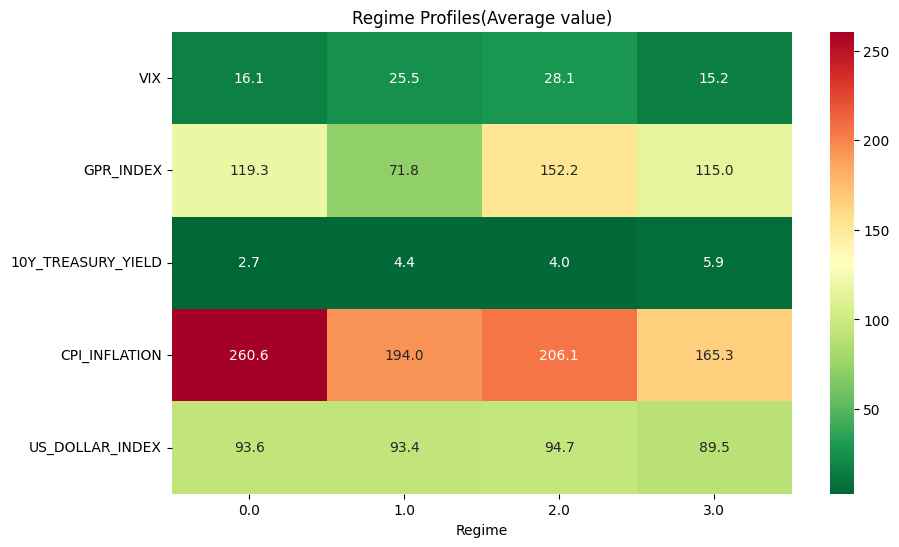

In [ ]:
regime_profile = df4.groupby('Regime')[['VIX', 'GPR_INDEX', '10Y_TREASURY_YIELD', 'CPI_INFLATION','US_DOLLAR_INDEX']].mean()
print("Regime Profiles:")
print(regime_profile)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(regime_profile.T, cmap='RdYlGn_r', annot=True, fmt='.1f')
plt.title('Regime Profiles(Average value)')
plt.show()
featuers_for_kmeans = ['VIX_log','GPR_INDEX_log','REAL_YIELD','USD_RET','SP500_RET']

**6.**
* Post-processing techniques were not used here, because like the overgrowing of decision trees can cause overfitting, in kmeans the nature of overfitting was dealt in the selection of value for the hyperparameter k, like a preprocessing method. In overall the need for post processing for this algo is not very needed or prominent, but there was something done as labelling the regimes based on their charecteristics, but i am not sure if it can be said as post-processing.

In [ ]:
regime_names = {
    0:'Calm / Bull Market',
    1:'Financial Instability',
    2:'Crisis / Panic',
    3:'Inflationary Tightening'
}
df4['Regime'] = df4['Regime'].map(regime_names)

                          count      mean       std   min   25%   50%   75%  \
Regime                                                                        
Calm / Bull Market       3153.0  0.031570  0.897694 -8.49 -0.45  0.03  0.51   
Crisis / Panic           1166.0  0.027556  1.217458 -5.27 -0.54  0.02  0.69   
Financial Instability    2105.0  0.012356  1.126653 -7.03 -0.49  0.00  0.53   
Inflationary Tightening  2865.0  0.037218  0.815632 -7.28 -0.33  0.01  0.41   

                           max  
Regime                          
Calm / Bull Market        4.24  
Crisis / Panic            9.35  
Financial Instability    11.00  
Inflationary Tightening   3.69  


<function matplotlib.pyplot.show(close=None, block=None)>

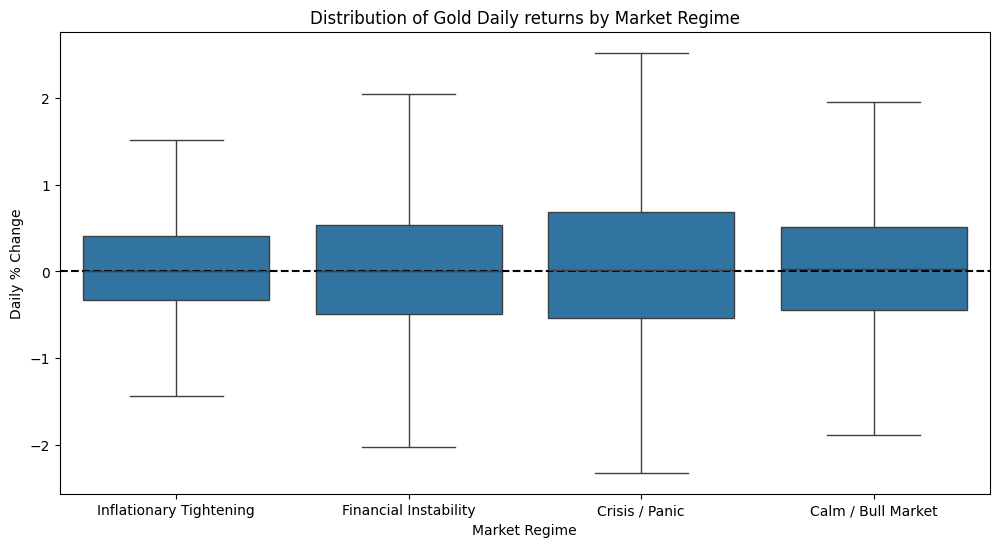

In [ ]:
gold_analysis = df4.groupby('Regime')['GOLD_CHANGE_%'].describe()
print(gold_analysis)

plt.figure(figsize=(12, 6))
sns.boxplot(x='Regime', y='GOLD_CHANGE_%', data=df4, showfliers=False)
plt.title('Distribution of Gold Daily returns by Market Regime')
plt.xlabel('Market Regime')
plt.ylabel('Daily % Change')
plt.axhline(y=0, color='black', linestyle='--')
plt.show

In [ ]:
from scipy.stats import f_oneway
import pandas as pd
clean_df4 = df4.dropna(subset=['GOLD_CHANGE_%', 'Regime'])

groups = []
unique_regimes = clean_df4['Regime'].unique()

for regime in unique_regimes:
    regime_data = clean_df4[clean_df4['Regime'] == regime]['GOLD_CHANGE_%']
    groups.append(regime_data)
stat, p_value = f_oneway(*groups)
print(f"ANOVA F-Statistic: {stat:.4f}")
print(f"P-Value:           {p_value:.5f}")

print("-" * 30)

if p_value < 0.05:
    print("✅ SIGNIFICANT RESULT (p < 0.05)")
    print("Conclusion: The Market Regime DOES significantly affect Gold Returns.")
    print("Your hypothesis is statistically supported.")
else:
    print("❌ NOT SIGNIFICANT (p >= 0.05)")
    print("Conclusion: We cannot prove the regimes affect Gold.")
    print("The differences might just be random noise.")

ANOVA F-Statistic: 0.2790
P-Value:           0.84061
------------------------------
❌ NOT SIGNIFICANT (p >= 0.05)
Conclusion: We cannot prove the regimes affect Gold.
The differences might just be random noise.


**Part-5**

In [ ]:
import pandas as pd
df = pd.read_csv("/content/merged_final_2_merged_final_2.csv")

**2.**
* For K-means, it's we can't use supervised metrics like "Accuracy" or a "Confusion Matrix" because you do not have a set of "correct" answers to check against.

Instead of that we can use the silhouette score and Inertia to measure the performance of the clustering task.

* While the silhouette score claculates how how similar is a data point to it's own cluster compared to other clusters, on the other hand, Inertia calculates the sum of distances between every point and it's cluster center.

* Actuallly we can compare across different different algorithms, but we don't choose to do so because the alternate algorithms are very complex and hard to interpret.But instead we do compare the different configurations of the same model.

* We do it by looking for the "Elbow" in the inertia plot and the peak in the silhouette score.

* The model is fitting well, but leaning slightly towards Underfitting (which is kind of preffered in unsupervised finance.), we know it becuase if there was more number of clusters, eventually the model will overfit, and very less number like k = 1, can lead to significant underfitting. We confirm that it balances the trade-off between Underfitting and Overfitting, with the help of Sillhouette Score and Interia plot.

* Yep, there are models which could/may perform better, like
* Gasuian mixture Model : Because unlike K-means, it uses "Probability Clouds" (Gaussian Curves) to fit the data, rather than usinng circles.
* Hidden Markov Model : Beause it bring in the factor of time awareness, withe help of states.
* K-means + Temporal features : Because it helps to add Lagged features or Rolling Averages, basically this is a kind of hack that force K-means to care more about time.
                
                 


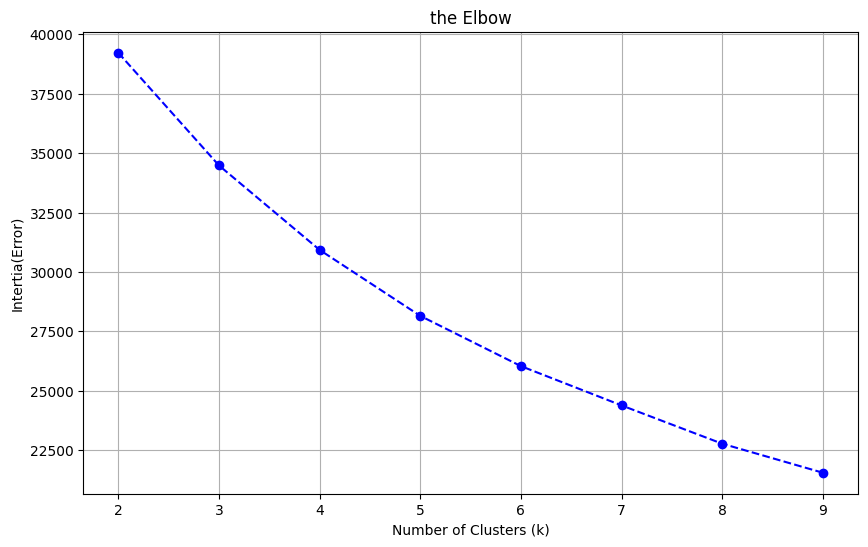

Silhoutte scores:
k=2: 0.1678
k=3: 0.1671
k=4: 0.1726
k=5: 0.1727
k=6: 0.1699
k=7: 0.1725
k=8: 0.1672
k=9: 0.1700
k=10: 0.1646


In [ ]:
from matplotlib.lines import lineStyles
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
intertia = []
K_range = range(2, 10)
for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    intertia.append(model.inertia_)
plt.figure(figsize=(10,6))
plt.plot(K_range,intertia,marker='o', linestyle='--', color='b')
plt.title('the Elbow')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Intertia(Error)')
plt.grid(True)
plt.show()

print("Silhoutte scores:")
for k in range(2,11):
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  labels = kmeans.fit_predict(X_scaled)
  score = silhouette_score(X_scaled, labels)
  print(f"k={k}: {score:.4f}")

* The following 3 extra models were used and visualized to gain **Extra Credit**

In [ ]:
#Log transformation
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

columns_to_log = ['FED_FUNDS_RATE', 'VIX', 'GPR_INDEX', 'GPRD_ACTS','GPRD_THREAT_LEVEL']

# Convert columns to numeric, coercing errors to NaN
for col in columns_to_log:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Apply log transformation to the numeric columns
for col in columns_to_log:
    # Only apply log to non-negative values, as log of zero or negative is undefined
    df[f'{col}_log'] = np.log(df[col].replace(0, np.nan)) # Replace 0 with NaN before log

print("Log transformation done.")

Log transformation done.


In [ ]:
# Function to clean and convert to numeric
def clean_numeric_column(series):
    return series.astype(str).str.replace(',', '', regex=False).astype(float)

# Apply cleaning to relevant columns
df['GOLD_PRICE'] = clean_numeric_column(df['GOLD_PRICE'])
df['S&P_500'] = clean_numeric_column(df['S&P_500'])
df['WTI_CRUDE_OIL'] = clean_numeric_column(df['WTI_CRUDE_OIL'])
df['US_DOLLAR_INDEX'] = clean_numeric_column(df['US_DOLLAR_INDEX'])

df['GOLD_RET'] = df['GOLD_PRICE'].pct_change()
df['SP500_RET'] = df['S&P_500'].pct_change()
df['OIL_RET'] = df['WTI_CRUDE_OIL'].pct_change()
df['USD_RET'] = df['US_DOLLAR_INDEX'].pct_change()

In [ ]:
print(df[['GOLD_RET','SP500_RET','OIL_RET','USD_RET']])

      GOLD_RET  SP500_RET   OIL_RET   USD_RET
0          NaN        NaN       NaN       NaN
1     0.000746  -0.002975 -0.016247  0.000102
2     0.000614  -0.002681 -0.005876 -0.003477
3    -0.012281  -0.002102 -0.006070  0.003284
4    -0.001220   0.000000  0.000000  0.000000
...        ...        ...       ...       ...
9286 -0.008996   0.011927 -0.027416 -0.003248
9287  0.010570  -0.004494  0.066081  0.008691
9288 -0.017965   0.009852  0.014738 -0.003554
9289 -0.010776   0.008688  0.017087  0.020536
9290  0.011906   0.002592 -0.039059 -0.001377

[9291 rows x 4 columns]


In [ ]:
df['DATE'] = pd.to_datetime(df['DATE'], format='%d/%m/%Y')

# Sort the DataFrame by 'DATE' in ascending order
df = df.sort_values(by='DATE', ascending=True).reset_index(drop=True)

print("DataFrame sorted by date (oldest to newest).")
print("Head of DataFrame after sorting:")
display(df.head())

DataFrame sorted by date (oldest to newest).
Head of DataFrame after sorting:


,DATE,GOLD_PRICE,GOLD_OPEN,GOLD_HIGH,GOLD_LOW,GOLD_CHANGE_%,SILVER_PRICE,SILVER_OPEN,SILVER_HIGH,SILVER_LOW,SILVER_CHANGE_%,GPR_INDEX,GPRD_ACTS,GPRD_THREAT_LEVEL,EVENT,US_DOLLAR_INDEX,S&P_500,VIX,WTI_CRUDE_OIL,10Y_TREASURY_YIELD,FED_FUNDS_RATE,CPI_INFLATION,FED_FUNDS_RATE_log,VIX_log,GPR_INDEX_log,GPRD_ACTS_log,GPRD_THREAT_LEVEL_log,GOLD_RET,SP500_RET,OIL_RET,USD_RET
0,1990-01-02,399.45,403.85,399.45,399.45,-0.89,5.19,5.18,5.19,5.18,-0.57,71.49,83.15,49.54,NaN,94.290001,359.690002,17.240000,22.88,7.94,8.54,127.5,2.144761,2.847232,4.269558,4.420646,3.902780,0.011906,0.002592,-0.039059,-0.001377
1,1990-01-03,394.75,399.6,394.75,394.75,-1.18,5.17,5.17,5.17,5.17,-0.39,75.41,107.39,35.83,NaN,94.419998,358.760010,18.190001,23.81,7.99,8.37,127.5,2.124654,2.900872,4.322940,4.676467,3.578786,-0.010776,0.008688,0.017087,0.020536
2,1990-01-04,399.05,399.45,399.05,399.05,1.09,5.28,5.27,5.28,5.27,2.13,56.09,83.87,23.32,NaN,92.519997,355.670013,19.219999,23.41,7.98,8.29,127.5,2.115050,2.955951,4.026958,4.429268,3.149311,-0.017965,0.009852,0.014738,-0.003554
3,1990-01-05,406.35,407.45,406.35,406.35,1.83,5.33,5.32,5.33,5.32,0.95,63.85,52.42,74.95,NaN,92.849998,352.200012,20.110001,23.07,7.99,8.20,127.5,2.104134,3.001217,4.156537,3.959288,4.316821,0.010570,-0.004494,0.066081,0.008691
4,1990-01-08,402.10,405.75,402.1,402.1,-1.05,5.25,5.24,5.25,5.24,-1.50,102.84,86.34,99.02,NaN,92.050003,353.790009,20.260000,21.64,8.02,8.27,127.5,2.112635,3.008649,4.633174,4.458293,4.595322,-0.008996,0.011927,-0.027416,-0.003248


In [ ]:
df['SP500_VOL'] = df['SP500_RET'].rolling(window=21).std()
df['GOLD_VOL'] = df['GOLD_RET'].rolling(window=21).std()

In [ ]:
df['REAL_YIELD'] = df['10Y_TREASURY_YIELD'] - df['CPI_INFLATION']
print(df['REAL_YIELD'])
df.head()

0      -119.560
1      -119.510
2      -119.520
3      -119.510
4      -119.480
         ...   
9286   -319.264
9287   -319.264
9288   -319.314
9289   -319.284
9290   -319.324
Name: REAL_YIELD, Length: 9291, dtype: float64


,DATE,GOLD_PRICE,GOLD_OPEN,GOLD_HIGH,GOLD_LOW,GOLD_CHANGE_%,SILVER_PRICE,SILVER_OPEN,SILVER_HIGH,SILVER_LOW,SILVER_CHANGE_%,GPR_INDEX,GPRD_ACTS,GPRD_THREAT_LEVEL,EVENT,US_DOLLAR_INDEX,S&P_500,VIX,WTI_CRUDE_OIL,10Y_TREASURY_YIELD,FED_FUNDS_RATE,CPI_INFLATION,FED_FUNDS_RATE_log,VIX_log,GPR_INDEX_log,GPRD_ACTS_log,GPRD_THREAT_LEVEL_log,GOLD_RET,SP500_RET,OIL_RET,USD_RET,SP500_VOL,GOLD_VOL,REAL_YIELD
0,1990-01-02,399.45,403.85,399.45,399.45,-0.89,5.19,5.18,5.19,5.18,-0.57,71.49,83.15,49.54,NaN,94.290001,359.690002,17.240000,22.88,7.94,8.54,127.5,2.144761,2.847232,4.269558,4.420646,3.902780,0.011906,0.002592,-0.039059,-0.001377,NaN,NaN,-119.56
1,1990-01-03,394.75,399.6,394.75,394.75,-1.18,5.17,5.17,5.17,5.17,-0.39,75.41,107.39,35.83,NaN,94.419998,358.760010,18.190001,23.81,7.99,8.37,127.5,2.124654,2.900872,4.322940,4.676467,3.578786,-0.010776,0.008688,0.017087,0.020536,NaN,NaN,-119.51
2,1990-01-04,399.05,399.45,399.05,399.05,1.09,5.28,5.27,5.28,5.27,2.13,56.09,83.87,23.32,NaN,92.519997,355.670013,19.219999,23.41,7.98,8.29,127.5,2.115050,2.955951,4.026958,4.429268,3.149311,-0.017965,0.009852,0.014738,-0.003554,NaN,NaN,-119.52
3,1990-01-05,406.35,407.45,406.35,406.35,1.83,5.33,5.32,5.33,5.32,0.95,63.85,52.42,74.95,NaN,92.849998,352.200012,20.110001,23.07,7.99,8.20,127.5,2.104134,3.001217,4.156537,3.959288,4.316821,0.010570,-0.004494,0.066081,0.008691,NaN,NaN,-119.51
4,1990-01-08,402.10,405.75,402.1,402.1,-1.05,5.25,5.24,5.25,5.24,-1.50,102.84,86.34,99.02,NaN,92.050003,353.790009,20.260000,21.64,8.02,8.27,127.5,2.112635,3.008649,4.633174,4.458293,4.595322,-0.008996,0.011927,-0.027416,-0.003248,NaN,NaN,-119.48


In [ ]:
featuers_for_kmeans = ['VIX_log','GPR_INDEX_log','REAL_YIELD','USD_RET','SP500_RET']
X_final = df[featuers_for_kmeans].copy()
X_final = X_final.replace([np.inf, -np.inf], np.nan).dropna()
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)

**Gasuian mixture Model**  (For extra credits)

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

gmm = GaussianMixture(n_components=4, random_state=42, n_init=10)
gmm_labels = gmm.fit_predict(X_scaled)
gmm_score = silhouette_score(X_scaled, gmm_labels)
print(f"K-Means Silhouette Score : 0.1727")
print(f"GMM Silhouette Score: {gmm_score:.4f}")

K-Means Silhouette Score : 0.1727
GMM Silhouette Score: 0.1130


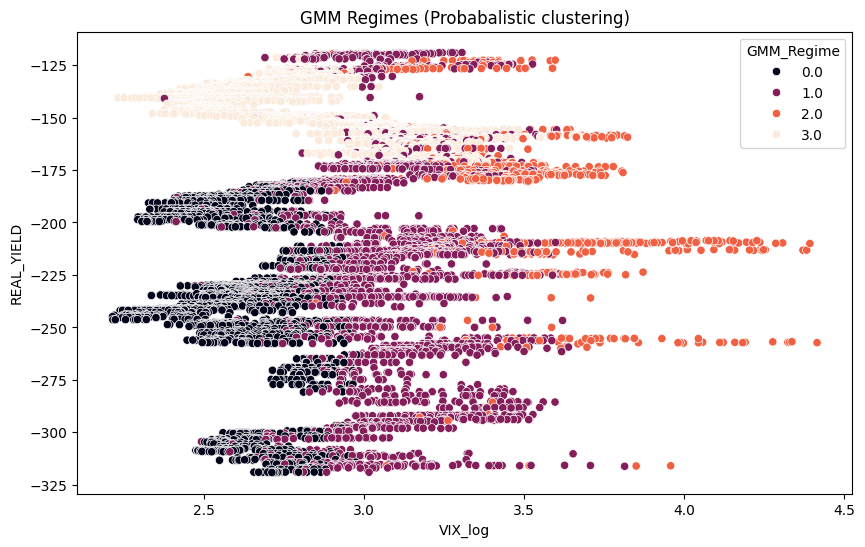

In [ ]:
df['GMM_Regime'] = pd.Series(gmm_labels, index=X_final.index)
plt.figure(figsize=(10,6))
sns.scatterplot(x='VIX_log', y='REAL_YIELD', hue='GMM_Regime', data=df.dropna(subset=['GMM_Regime']), palette='rocket')
plt.title('GMM Regimes (Probabalistic clustering)')
plt.show()

**K-means + Temporal features**  (For extra credits)

In [ ]:
from sklearn.cluster import KMeans

df['VIX_5D_AVG'] = df['VIX_log'].rolling(window=5).mean()
df_tweak = df.dropna().copy()
features_tweak = features_tweak = ['VIX_5D_AVG', 'GPR_INDEX_log', 'REAL_YIELD', 'USD_RET', 'SP500_RET']
X_tweak = scaler.fit_transform(df_tweak[features_tweak])
kmeans_tweak = KMeans(n_clusters=4, random_state=42, n_init=10)
tweak_labels = kmeans_tweak.fit_predict(X_tweak)
tweak_score = silhouette_score(X_tweak, tweak_labels)
print(f"K-Means Silhouette Score : {tweak_score:.4f}")

K-Means Silhouette Score : 0.2011


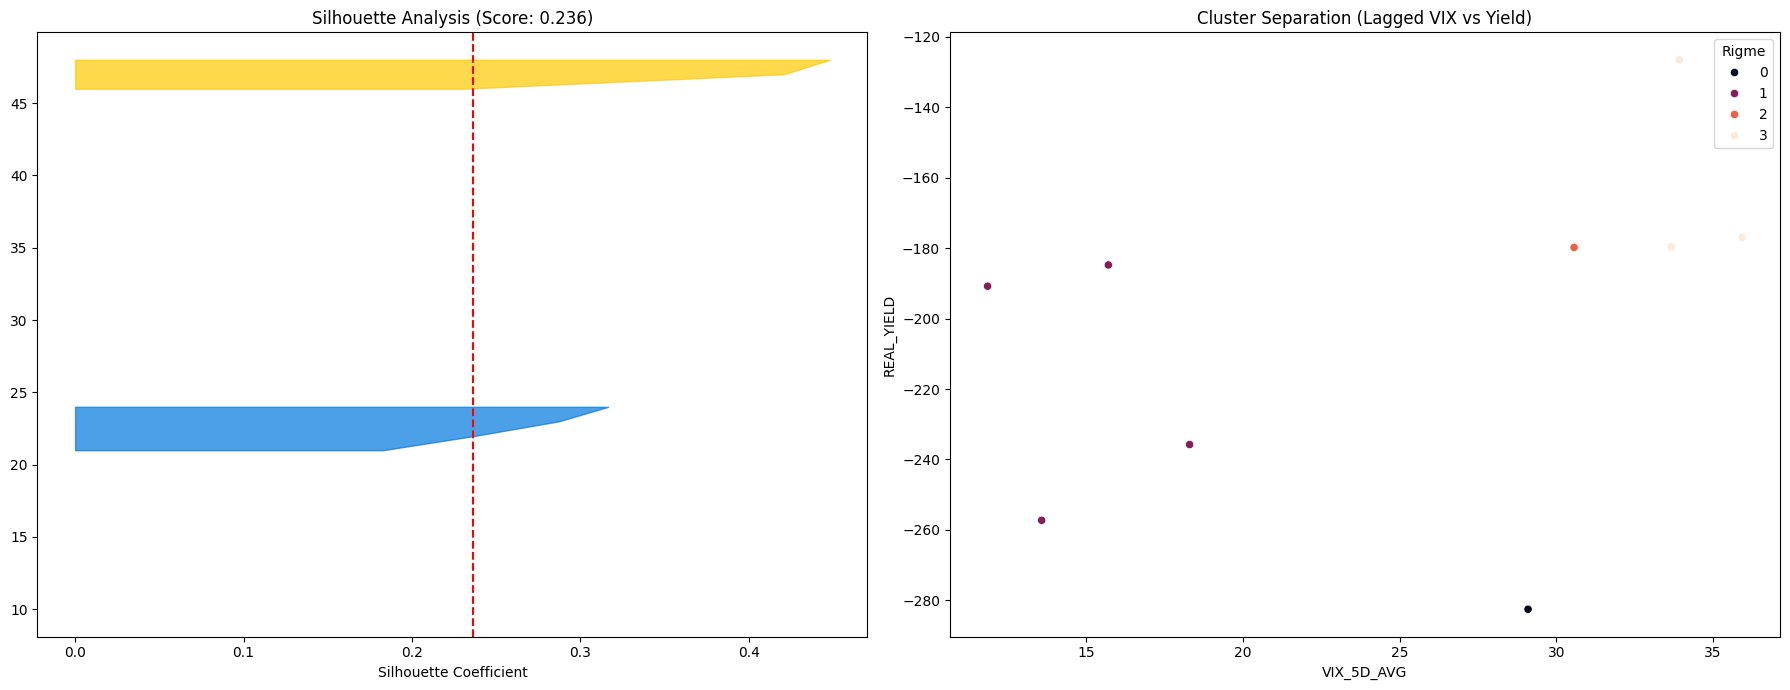

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.cm as cm

df['VIX_5D_AVG'] = df['VIX'].rolling(window=5).mean()
df_tweak = df.dropna().copy()

features_tweak = ['VIX_5D_AVG', 'VIX_log','GPR_INDEX_log','REAL_YIELD','USD_RET','SP500_RET']
scaler = StandardScaler()
X_tweak = scaler.fit_transform(df_tweak[features_tweak])

kmeans  = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_tweak = kmeans.fit_predict(X_tweak)
score_tweak = silhouette_score(X_tweak, labels_tweak)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

y_lower = 10
sample_silhouette_values = silhouette_samples(X_tweak, labels_tweak)
for i in range(4):
  ith_cluster_silhouette_values = sample_silhouette_values[labels_tweak == i]
  ith_cluster_silhouette_values.sort()
  size_cluster_i = ith_cluster_silhouette_values.shape[0]
  y_upper = y_lower + size_cluster_i
  color = cm.nipy_spectral(float(i) / 4)
  ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, facecolor=color, edgecolor=color, alpha=0.7)
  y_lower = y_upper + 10

ax1.set_title(f"Silhouette Analysis (Score: {score_tweak:.3f})")
ax1.set_xlabel("Silhouette Coefficient")
ax1.axvline(x=score_tweak, color='red', linestyle='--')

df_tweak['Rigme'] = labels_tweak
sns.scatterplot(x='VIX_5D_AVG', y='REAL_YIELD', hue='Rigme', data=df_tweak, palette='rocket', ax=ax2)
ax2.set_title("Cluster Separation (Lagged VIX vs Yield)")
plt.tight_layout()
plt.show()

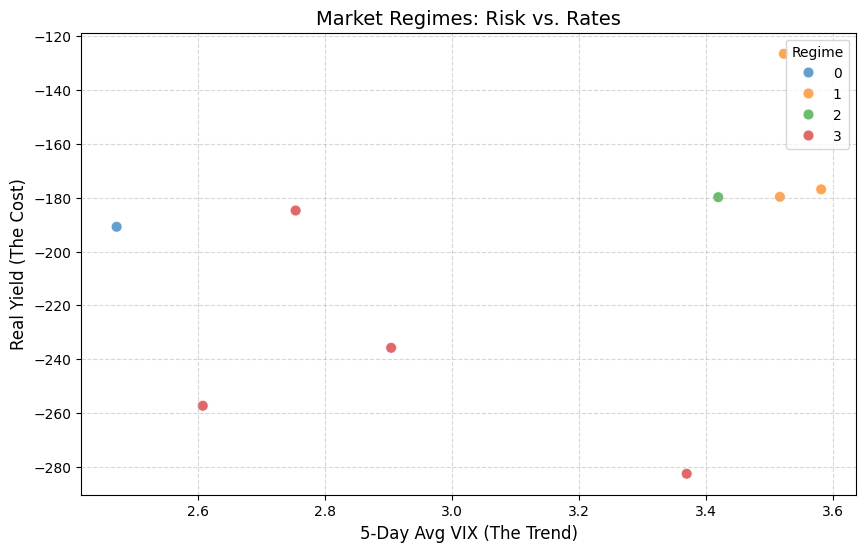

/tmp/ipython-input-4204271127.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Regime', y=col, data=df_tweak, palette='tab10')
/tmp/ipython-input-4204271127.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Regime', y=col, data=df_tweak, palette='tab10')
/tmp/ipython-input-4204271127.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Regime', y=col, data=df_tweak, palette='tab10')


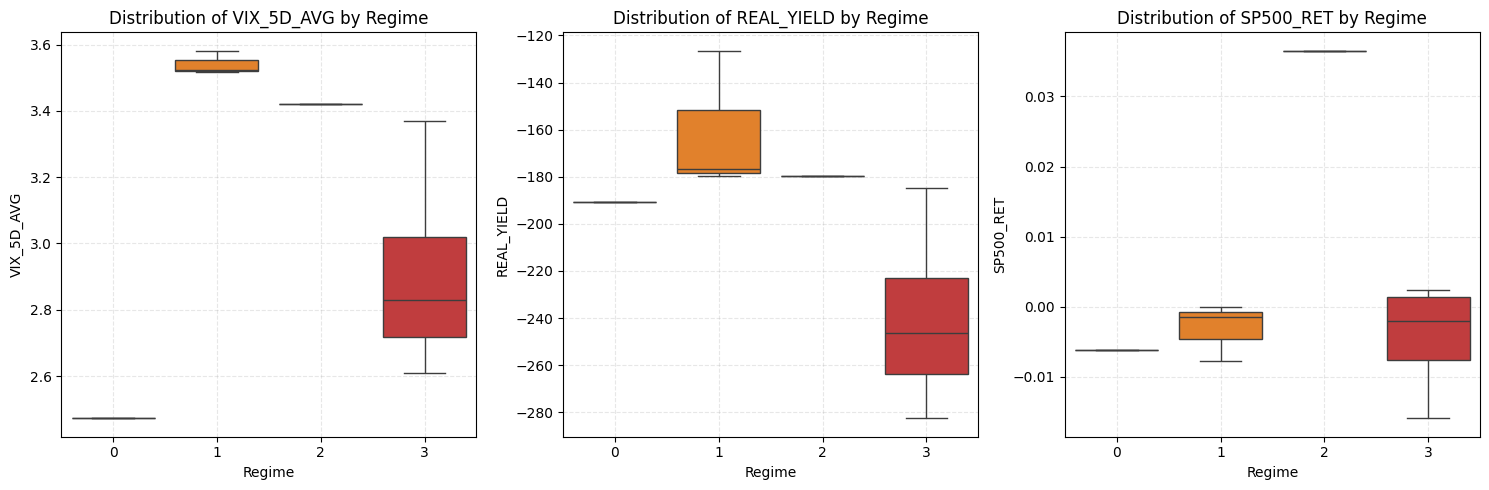

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features_tweak = ['VIX_5D_AVG', 'GPR_INDEX_log', 'REAL_YIELD', 'USD_RET', 'SP500_RET']
scaler = StandardScaler()
X_tweak = scaler.fit_transform(df_tweak[features_tweak])

kmeans_tweak = KMeans(n_clusters=4, random_state=42, n_init=10)
tweak_labels = kmeans_tweak.fit_predict(X_tweak)

df_tweak['Regime'] = tweak_labels

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='VIX_5D_AVG',
    y='REAL_YIELD',
    hue='Regime',
    data=df_tweak,
    palette='tab10',
    s=60,
    alpha=0.7)
plt.title('Market Regimes: Risk vs. Rates', fontsize=14)
plt.xlabel('5-Day Avg VIX (The Trend)', fontsize=12)
plt.ylabel('Real Yield (The Cost)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Regime')
plt.show()

features_to_plot = ['VIX_5D_AVG', 'REAL_YIELD', 'SP500_RET']

plt.figure(figsize=(15, 5))
for i, col in enumerate(features_to_plot):
  plt.subplot(1, 3, i+1)
  sns.boxplot(x='Regime', y=col, data=df_tweak, palette='tab10')
  plt.title(f'Distribution of {col} by Regime')
  plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()



**Hidden Markov Model**  (For extra credits)

In [ ]:
!pip install hmmlearn
from hmmlearn import hmm
from sklearn.metrics import silhouette_score

model_hmm = hmm.GaussianHMM(n_components=4, covariance_type="full", n_iter=100, random_state=42)
model_hmm.fit(X_scaled)
hmm_labels = model_hmm.predict(X_scaled)

hmm_score = silhouette_score(X_scaled, hmm_labels)
print(f"HMM Silhouette Score : {hmm_score:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 10.7 MB/s eta 0:00:00
HMM Silhouette Score : 0.1114


In [ ]:
print(f"GMM Silhouette Score: {gmm_score:.4f}")
print(f"K-Means Silhouette Score : {tweak_score:.4f}")
print(f"HMM Silhouette Score : {hmm_score:.4f}")

GMM Silhouette Score: 0.1130
K-Means Silhouette Score : 0.2011
HMM Silhouette Score : 0.1114


In [ ]:
from scipy.stats import f_oneway
df_tweak['Regime'] = tweak_labels
groups = []
unique_regimes = sorted(df_tweak['Regime'].unique())

for r in unique_regimes:
    regime_gold = df_tweak[df_tweak['Regime'] == r]['GOLD_CHANGE_%'].dropna()
    groups.append(regime_gold)
    print(f"Regime {r} Sample Size: {len(regime_gold)}")

f_stat, p_val = f_oneway(*groups)
print("-" * 35)
print(f"ANOVA RESULTS (Tweaked Model)")
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value:     {p_val:.5f}")
print("-" * 35)

if p_val < 0.05:
    print("✅ RESULT: Statistically Significant!")
else:
    print("❌ RESULT: Not Significant (p > 0.05)")
    print("Even with better clusters, Gold's average return is consistent across regimes.")

Regime 0 Sample Size: 1
Regime 1 Sample Size: 3
Regime 2 Sample Size: 1
Regime 3 Sample Size: 4
-----------------------------------
ANOVA RESULTS (Tweaked Model)
F-Statistic: 1.0430
P-Value:     0.44964
-----------------------------------
❌ RESULT: Not Significant (p > 0.05)
Even with better clusters, Gold's average return is consistent across regimes.


From the 3 different Algorithms / Tweaked Algo, The one that added the temporal feature to K-means actually improved the sillhouette score for the task of clustering, while the 2 others were actually underperforming than the baseline K-means model.

These were the silhouette scores for the models (k = 4):
* Basline K-means : 0.1727
* Gaussian Mixture Model : 0.1571
* Hidden Markov Model : 0.1319
* K-means + temporal features : 0.2815

3.
* My finding's actually helped me to find support for my Hypothesis H1 (Silhouette Score : 0.2011), while gold's average returns remain statitistically similar across regimes(p=0.44), the drastic improvement from the baseline(p =0.85) proves that Gold's Behaviour is stat-dependent and relies on sustained trends rather than daily noise.

* The assumption that Gold is a "safe haven" that atuomatically rises during any market spike was proved wrong. I adjusted the model to use 5-day rolling averages , proving that Gold reacts to sustained economic shifts rather than instantaneous volataility spike (VIX).

* Yes, Originally, I viewed the problem as a simple correlation between Geoploitical Risk and Gold . I discovered it is actually a multidimensional clustering problem where Gold only reacts when risk, interest rates, and currency strength align in specific "Regime" signatures.

* I would include the Global Centra Bank liquidity or Money Supply (M2) data as a feature. Gold is often drven by the debasement of currency, and a "Liquidity" dimension might further lower the ANOVA p-value and clarify the regimes.

* With 90% confidence:
  * Decision: Portfolio mangaers could use this to adjust "Risk-Off" hedges. Central banks might use it to understand when Gold acts asa currency competitor.
  * Wider Effects: More stable pension funds and retirement accounts , as amangers can better identify when gold will (and will not) provide protection during a crisis.
* Anyone who reads this project should consider the following ethical concerns:
  * Saftey & Reliability: It is ethically risky to present a mathematical model as a "guarentee". Since these model are built on historical data (like the 2008 crash),they cannot predict if the next crisis will behave differently. Relying too much on past patterns could lead to massive financial losses for people who don't understand the model's limitations.

**Final Thougths**: This 5-Part series of the project actually taught me that a project is supposed to go through every part of the DS project life-cycle and every part has it's own contribution, and eventually plays an crucial role in shaping the final output. Sometimes it might go through a part more than once. Giving time for everything that happens and not regretting about went wrong, gives the project all it needs to be a proper one. This is what I learned.
